# Open quantum systems I — the Lindblad master equation on a density tensor

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 6 — Open quantum systems*

## 1. Introduction and motivation

Every notebook so far has solved the Schrödinger equation $i\,\partial_t|\psi\rangle = H|\psi\rangle$: the spin
chain was **closed**, perfectly isolated from the rest of the universe. No laboratory system is like that. An atom
in an excited state emits a photon and the photon flies away; the phase of a superconducting qubit is scrambled by
fluctuating charges in the substrate; a Rydberg atom decays spontaneously to lower levels; a trapped ion feels noisy
electric fields. In all these cases the system we care about (a few spins) talks to an **environment** with an
astronomically large number of degrees of freedom that we can neither control nor simulate.

Two things happen to such an **open quantum system**:

* **dissipation** — energy (or particles) leaks into the environment: populations relax, on a time scale called $T_1$;
* **decoherence** — superpositions lose their definite phase: interference disappears, on a time scale called $T_2$.

$T_1$ and $T_2$ are the two numbers every quantum-hardware paper quotes first, because they limit how long a quantum
computation, a quantum memory or a quantum sensor can work. But dissipation is not only an enemy. Driven-dissipative
systems relax to **steady states** that can be magnetically ordered, entangled, or even topological;
optical pumping *is* engineered dissipation: it prepares atoms in a chosen internal state. Understanding (and simulating) open many-body systems
is an active research field.

The state of an open system is not a vector $|\psi\rangle$ but a **density matrix** $\rho$
(introduced in [notebook 07 (Chapter 3)](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb)), and the
Schrödinger equation is replaced by the **Lindblad master equation**, also called the GKSL equation after
Gorini, Kossakowski, Sudarshan and Lindblad (1976):

$$ \frac{d\rho}{dt} = -i[H,\rho] + \sum_j \gamma_j\Big( L_j\,\rho\,L_j^\dagger - \tfrac12\big\{L_j^\dagger L_j,\rho\big\}\Big). $$

This notebook is about this equation: where it comes from, what each term means, and — the main subject here — how to
solve it numerically for many spins **without ever building a big matrix**.

**Road map.**

1. Section 2 motivates the equation: starting from the Kraus channels of notebook 07 we build the most general
   memoryless, physically consistent evolution, name the approximations a real bath must satisfy, quote the GKSL
   theorem (nothing else is possible) and show which parts of $(H,\{L_j\})$ are convention rather than physics.
2. Section 3 solves one qubit by hand ($T_1$ decay, $T_2$ dephasing, the driven-dissipative steady state and damped Rabi
   oscillations) and checks a first, literal implementation against these formulas.
3. Section 4 is the core: $\rho$ becomes a tensor of rank $2N$ and the products $O\rho$, $\rho\,O$, $L\rho L^\dagger$ become
   single einsum contractions — the **left/right multiplication trick**. We validate the matrix-free Lindbladian
   against two independent dense references.
4. Sections 5–7 are about time stepping: Euler (fails), Runge–Kutta 4 with `lax.scan`, the **Trotter–Kraus** step,
   their measured convergence orders (1, 4, 1 and — with a small improvement — 2), and what each method does to
   the three defining properties of a density matrix: trace, Hermiticity, positivity.
5. Section 8 is physics: a dissipative XXZ chain, driven to the maximally mixed state by dephasing, a
   structured steady state under decay, the spectrum of the Lindbladian and the relaxation gap.
6. Section 9 measures the cost, $O(4^N)$, and explains why the *next* notebook (quantum trajectories) exists.

### What you will learn

**Physics**

* what the terms of the Lindblad equation mean; the Born, Markov and secular approximations behind them; jump operators
  for decay ($\sigma^-$), pumping ($\sigma^+$), dephasing ($\sigma^z$) and bit flips ($\sigma^x$), and the freedom in choosing them;
* $T_1$, $T_2$ and the relation $1/T_2 = 1/(2T_1) + 1/T_\varphi$; optical Bloch equations, saturation, damped Rabi oscillations;
* the maximally mixed state versus structured steady states in a dissipative spin chain; purity and entropy production; the Liouvillian gap.

**Numerical methods**

* the Lindbladian as a linear map on $4^N$ numbers, applied matrix-free at cost $O(N\,4^N)$ per evaluation;
* explicit Runge–Kutta integration (order, stability limit) versus a completely positive operator splitting (Trotter–Kraus);
* how to measure convergence orders and how to monitor trace / Hermiticity / positivity.

**Implementation practice**

* reuse of `apply_gate` on ket *and* bra axes; building einsum strings by hand for a small case before trusting the general code;
* `lax.scan` for time loops with recorded observables, `lax.fori_loop` with a *traced* trip count for parameter studies without recompilation, `vmap` over a drive strength;
* validation against analytic results and against a dense superoperator on small $N$; honest timing (compile versus run).

### Prerequisites
* [Notebook 05 (Chapter 3) — matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb): `apply_gate`, Hamiltonians as lists of local terms;
* [Notebook 07 (Chapter 3) — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb): density operator, density **tensor**, Kraus channels, `apply_kraus_dm`;
* [Notebook 12 (Chapter 5) — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb): Trotter–Suzuki splitting and `tebd_gates`;
* [Notebook 01 (Chapter 1) — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan`.

Units: $\hbar = 1$ everywhere; energies and rates are measured in units of the exchange coupling $J$, times in units of $1/J$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
SM = jnp.array([[0, 1], [0, 0]], dtype=CDTYPE)  # sigma^- = |0><1| : lowers |1> -> |0>
SP = SM.conj().T                                # sigma^+ = |1><0|
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))

def expect_local_dm(rho, O, qubits):
    """Tr(rho O_qubits) for a density tensor, via its reduced density matrix."""
    return jnp.real(jnp.trace(rdm_dm(rho, qubits) @ jnp.asarray(O, dtype=CDTYPE)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) sigma^-)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])

def kraus_from_jump(L, gamma_dt):
    """Kraus pair generated by a Lindblad jump operator L acting for a short time dt (rate gamma):
        K1 = sqrt(gamma dt) L                      'a jump happened'
        K0 = sqrt(1 - gamma dt L^dag L)            'no jump'  (~ exp(-gamma dt L^dag L / 2))
    Completeness K0^dag K0 + K1^dag K1 = 1 holds EXACTLY whenever gamma dt ||L^dag L|| <= 1, so that
    1 - gamma dt L^dag L is positive semidefinite and its square root exists; the map is then trace preserving.
    For larger steps the negative eigenvalues are clipped by _sqrtm_psd and completeness FAILS (L = sigma^-,
    gamma dt = 1.5: error 0.5).  It reproduces the Lindblad dissipator up to O(dt^2)."""
    L = jnp.asarray(L, dtype=CDTYPE)
    K0 = _sqrtm_psd(jnp.eye(L.shape[0], dtype=CDTYPE) - gamma_dt * (L.conj().T @ L))
    return jnp.stack([K0, jnp.sqrt(gamma_dt) * L])


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates_dm(rho, gates):
    """Same circuit on a density tensor (U on kets, U^* on bras)."""
    for qubits, U in gates:
        rho = apply_gate_dm(rho, U, qubits)
    return rho


# ----------------------------------------------------------------------------
# 10. Open systems: Lindblad master equation (density tensor) and quantum trajectories (MCWF)
# ----------------------------------------------------------------------------
def lindblad_trotter_step_dm(rho, gates, jump_kraus):
    """Trotterised Lindblad step on a density tensor: unitary TEBD gates, then one Kraus channel per
    jump operator (`jump_kraus` = [(qubits, kraus_from_jump(L, gamma*dt)), ...]).
    Completely positive and trace preserving by construction, first order in the dissipator."""
    rho = apply_gates_dm(rho, gates)
    for q, K in jump_kraus:
        rho = apply_kraus_dm(rho, K, q)
    return rho


## 2. From closed to open systems: the GKSL equation

### 2.1 Why a density matrix, and what a physical evolution must respect

Recall from [notebook 07 (Chapter 3)](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb): if the system S is
entangled with an environment E, there is **no** state vector for S alone. All predictions for measurements on S
follow from the reduced density matrix $\rho = \mathrm{Tr}_E\,|\Psi_{SE}\rangle\langle\Psi_{SE}|$, a matrix with three
defining properties:

| property | formula | meaning |
|---|---|---|
| Hermitian | $\rho^\dagger=\rho$ | probabilities are real |
| unit trace | $\mathrm{Tr}\,\rho = 1$ | probabilities sum to one |
| positive semi-definite | all eigenvalues $p_k\ge 0$ | probabilities are non-negative |

The expectation value of an observable is $\langle O\rangle = \mathrm{Tr}(\rho\,O)$, the purity $\mathrm{Tr}\rho^2$ equals 1
only for pure states $\rho=|\psi\rangle\langle\psi|$.

### 2.1b Tracing out the environment, exactly

Before any approximation, ask what the evolution of $\rho$ looks like in general. Two ingredients are needed.

**(i) An uncorrelated preparation.** Assume system and environment start independently,
$\rho_{\rm tot}(0)=\rho(0)\otimes\rho_E$, with the environment in a fixed reference state (thermal, or its ground
state at zero temperature). This is a real restriction: if the two start *correlated*, the later state of the system
depends on correlations that $\rho(0)$ does not record, and then no function of $\rho(0)$ alone can produce
$\rho(t)$ - Exercise 1 builds a two-line counterexample with a swap.

**(ii) A partial trace in the environment's own eigenbasis.** Evolve the pair unitarily and trace out the
environment, diagonalising the reference state as $\rho_E=\sum_\nu\lambda_\nu|\phi_\nu\rangle\langle\phi_\nu|$:

$$ \rho(t)=\mathrm{Tr}_E\big[U(t)\,(\rho(0)\otimes\rho_E)\,U^\dagger(t)\big]
   =\sum_{\mu\nu}\lambda_\nu\,M_{\mu\nu}\,\rho(0)\,M_{\mu\nu}^\dagger ,\qquad
   M_{\mu\nu}=\langle\phi_\mu|U(t)|\phi_\nu\rangle . $$

Each $M_{\mu\nu}$ acts on the system alone - it is what is left of the joint propagator once the environment bra and
ket have been contracted, exactly the kind of contraction notebook 03 performs. Absorbing $\sqrt{\lambda_\nu}$ and
writing a single label $k$,

$$ \rho(t)=\sum_k A_k\,\rho(0)\,A_k^\dagger ,\qquad \sum_k A_k^\dagger A_k=\mathbb{1} , \tag{1}$$

where the second identity follows from $U^\dagger U=\mathbb{1}$ and completeness of the $|\phi_\mu\rangle$, and is
what makes $\mathrm{Tr}\,\rho(t)=\mathrm{Tr}\,\rho(0)$ at all times. **Equation (1) is exact**: any coupling
strength, any environment, no approximation. Its price is that the $A_k$ are as unknowable as the environment. (In
the language of notebook 07 this is the Kraus form of a quantum channel; nothing below needs that vocabulary.)

> **The label $k$ is a record.** It says which state the environment was left in. Summing over it - not reading it -
> gives the master equation of this notebook. *Reading* it gives the quantum trajectories of notebook 17: the
> likeliest outcome leaves the system in $A_0|\psi\rangle$, whose norm is less than one because learning that
> nothing happened is information, and a rare outcome leaves it in $L_j|\psi\rangle$ - a click in a detector. The
> two methods are one derivation read two ways.

### 2.1c Where the jump operators come from

So far $L_j$ is "whatever the small operators are". They are not arbitrary. Any physical coupling is a sum of
products of a system operator with an environment operator,

$$ V=\sum_\alpha S_\alpha\otimes E_\alpha , $$

because that is what "the two act on each other" means. Expand $M_{\mu\nu}=\langle\phi_\mu|U|\phi_\nu\rangle$
for a short interval, $U\simeq\mathbb{1}-iV\,dt$, and read off the piece with $\mu\neq\nu$, i.e. the environment
changing state:

$$ M_{\mu\nu}\simeq-i\,dt\sum_\alpha S_\alpha\,\langle\phi_\mu|E_\alpha|\phi_\nu\rangle\qquad(\mu\neq\nu). $$

The operator acting on the system is $S_\alpha$ - **the system operator that appears in the coupling** - and the
number multiplying it is the amplitude for the environment to make that transition. A jump operator is the system's
half of the interaction; its rate is the environment's half, squared and summed over all the ways the environment
can absorb what the system gives it. That sum is Fermi's golden rule: the rate is the environment's spectral density
at the transition frequency.

* **Spin in the electromagnetic vacuum.** $V=g(\sigma^-\otimes a^\dagger+\sigma^+\otimes a)$. From the vacuum the
  only environment transition is "no photon $\to$ one photon", whose system partner is $\sigma^-$. Hence
  $L=\sigma^-$: spontaneous emission.
* **Thermal environment.** The environment can also give a quantum back, so "one photon $\to$ none" contributes with
  system partner $\sigma^+$. Two jump operators, their rates in a ratio fixed by temperature.
* **Fluctuating field along $z$.** $V=Z\otimes B$: the environment learns the spin direction and exchanges no
  energy. The system operator in the coupling is $Z$, so $L=Z$ - pure dephasing, populations untouched.

In a many-body system the same reading applies site by site: a bath on each spin gives one jump operator per site,
which is the list used in Sec. 8.

### 2.2 Where a master equation comes from (the physical picture)

The honest derivation starts from the Schrödinger equation of system **plus** bath, $H_{\rm tot} = H + H_E + H_{\rm int}$,
and traces out the bath. Three approximations make the result tractable (we quote them without proof; see
Breuer & Petruccione, chapter 3):

1. **Born** (weak coupling): the bath is so large that the system does not change it appreciably;
2. **Markov** (no memory): bath correlations decay much faster than the system evolves — whatever leaks into the
   bath never comes back. The photon emitted by an atom in free space is the prime example;
3. **secular / rotating-wave**: rapidly oscillating terms average out.

The outcome is a first-order differential equation $\dot\rho = \mathcal{L}(\rho)$ in which the bath survives only
through a handful of **rates** $\gamma_j$ and **jump operators** $L_j$ (the system operators through which the bath
acts). We do not carry out this microscopic calculation. Instead we give a **consistency argument**: we postulate the
form that a memoryless evolution must take and show that it forces Eq. (2) below. The argument explains where every
term comes from and prepares the numerical methods, but it is not a derivation from $H_{\rm tot}$: the rates
$\gamma_j$ and the operators $L_j$ stay unspecified, and only the microscopic calculation (or an experiment) fixes them.

### 2.3 The most general memoryless evolution

*Markov assumption:* the state at $t+dt$ depends only on the state at $t$, through a channel (1) that is the same at all
times and that becomes the identity for $dt\to0$:
$\rho(t+dt) = \sum_m K_m\rho(t)K_m^\dagger = \rho(t) + O(dt)$.

How can a sum of terms $K_m\rho K_m^\dagger$ differ from $\rho$ only at order $dt$? We *assume* the Kraus operators
organise themselves in the two ways one expects from a Taylor expansion in $\sqrt{dt}$ (this assumption is the
non-rigorous step; the theorem quoted at the end of this section is what removes it).

* **One** Kraus operator is close to the identity: $K_0 = \mathbb{1} + G\,dt$ with some matrix $G$. Every matrix
  can be split into a Hermitian and an anti-Hermitian part, so we write $G = -iH - A$ with $H=H^\dagger$ and $A=A^\dagger$.
* **All the others** are small, of order $\sqrt{dt}$, so that $K\rho K^\dagger$ is of order $dt$:
  $K_j = \sqrt{\gamma_j\,dt}\;L_j$, $j=1,2,\dots$ with arbitrary operators $L_j$ and rates $\gamma_j\ge0$.

Now impose the completeness relation of Eq. (1), keeping terms up to order $dt$:

$$ K_0^\dagger K_0 + \sum_j K_j^\dagger K_j = \mathbb{1} + \Big(\underbrace{iH - iH}_{0} - 2A + \sum_j\gamma_j L_j^\dagger L_j\Big)dt + O(dt^2) \overset{!}{=} \mathbb{1}
\quad\Longrightarrow\quad A = \tfrac12\sum_j\gamma_j L_j^\dagger L_j . $$

The anti-Hermitian part of $K_0$ is *not free*: it is dictated by the jump operators. Insert everything into the channel:

$$ \rho(t+dt) = (\mathbb{1}-iH\,dt - A\,dt)\,\rho\,(\mathbb{1}+iH\,dt - A\,dt) + dt\sum_j\gamma_j L_j\rho L_j^\dagger + O(dt^2)
  = \rho + dt\Big(-i[H,\rho] - \{A,\rho\} + \sum_j\gamma_j L_j\rho L_j^\dagger\Big) + O(dt^2). $$

Divide by $dt$, let $dt\to0$ and insert $A$:

$$ \boxed{\;\frac{d\rho}{dt} = \mathcal{L}(\rho) = -i[H,\rho] + \sum_j\gamma_j\,\mathcal{D}[L_j](\rho),\qquad
   \mathcal{D}[L](\rho) = L\rho L^\dagger - \tfrac12\{L^\dagger L,\rho\}\;} \tag{2}$$

This is the **GKSL (Lindblad) master equation**. $\mathcal{L}$ is called the **Lindbladian** or Liouvillian,
$\mathcal{D}[L]$ the **dissipator** of the jump operator $L$.

> **GKSL theorem** (Gorini, Kossakowski and Sudarshan; Lindblad; both 1976). Let $\{e^{\mathcal{L}t}\}_{t\ge0}$ be a
> one-parameter **semigroup** — $e^{\mathcal{L}(t+s)}=e^{\mathcal{L}t}e^{\mathcal{L}s}$, $e^{\mathcal{L}0}=\mathrm{id}$ —
> of completely positive, trace-preserving maps, continuous in $t$. On a finite-dimensional Hilbert space its generator
> $\mathcal{L}$ **must** have the form (2), with $H=H^\dagger$ and finitely many $L_j$, $\gamma_j\ge0$. Gorini,
> Kossakowski and Sudarshan proved it for $N$-level systems; Lindblad proved it in infinite dimension for generators
> that are bounded in operator norm.

The theorem is what turns Section 2.3 from a plausible ansatz into a statement about *all* memoryless evolutions:
nothing else than (2) is possible. The three physical words in it are *completely positive* (defined in
[notebook 07 (Chapter 3)](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb): positivity must
survive when the system is viewed as part of a larger one), *trace preserving* (probability), and *semigroup*
(memorylessness: evolving for $t+s$ is the same as evolving for $t$ and then for $s$, with no reference to what
happened before). A bath with memory violates the last property, and then no Lindblad equation exists.

**Reading the equation.**

* $-i[H,\rho]$ — ordinary coherent dynamics (for $\gamma_j=0$ and $\rho=|\psi\rangle\langle\psi|$ this *is* the Schrödinger equation).
* $L\rho L^\dagger$ — the "**jump**" (or *recycling*) term: with probability $\gamma\,dt\,\mathrm{Tr}(L^\dagger L\rho)$ per time step the
  environment does something to the system (absorbs a photon, flips a phase, ...), and the state becomes $\propto L\rho L^\dagger$.
* $-\tfrac12\{L^\dagger L,\rho\}$ — the price for probability conservation. It removes exactly as much trace as the
  jump term adds: $\mathrm{Tr}\,\mathcal{D}[L](\rho) = \mathrm{Tr}(L^\dagger L\rho) - \mathrm{Tr}(L^\dagger L\rho) = 0$ by cyclicity of the trace.
  Together with $H$ it forms the non-Hermitian **effective Hamiltonian** $H_{\rm eff} = H - \tfrac i2\sum_j\gamma_jL_j^\dagger L_j$,
  which governs the [next notebook](17_monte_carlo_wave_function.ipynb).

### 2.4 The jump operators used in this notebook

Our basis convention: $|0\rangle=(1,0)^T$ is the $+1$ eigenstate of $Z$ ("up"), $|1\rangle=(0,1)^T$. For a single qubit we take
$|1\rangle$ as the *excited* level that decays to $|0\rangle$, consistent with the amplitude-damping channel of notebook 07.

| name | $L$ | engine | $L^\dagger L$ | what the bath does | physical example |
|---|---|---|---|---|---|
| decay (relaxation) | $\sigma^- = \lvert0\rangle\langle1\rvert$ | `SM` | $\lvert1\rangle\langle1\rvert$ | takes away one excitation | spontaneous emission |
| pumping | $\sigma^+ = \lvert1\rangle\langle0\rvert$ | `SP` | $\lvert0\rangle\langle0\rvert$ | adds one excitation | incoherent (optical) pumping |
| dephasing | $\sigma^z$ | `Z` | $\mathbb{1}$ | measures $Z$ without telling us | fluctuating magnetic field |
| bit flip | $\sigma^x$ | `X` | $\mathbb{1}$ | random spin flips | transverse noise |

For many spins each site has its own, independent bath: $L_j$ acts on site $j$ only. Exactly like a Hamiltonian is a
list of local terms `[(qubits, h), ...]`, the dissipation is a list `jumps = [(qubits, L, gamma), ...]`.

> **Physics insight.** For a Hermitian jump operator with $L^2=\mathbb 1$ (dephasing, bit flip) the dissipator is
> $\mathcal D[L](\rho) = L\rho L - \rho$: the bath applies $L$ at random times. Such noise is **unital**
> ($\mathcal{L}(\mathbb 1)=0$): the maximally mixed state $\mathbb 1/2^N$ is always a steady state, and such noise can only make the state more mixed.
> Decay is different: $\mathcal{D}[\sigma^-](\mathbb 1) = \sigma^-\sigma^+ - \sigma^+\sigma^- = Z \neq 0$. It pumps the
> system towards the pure state $|0\rangle$: decay can *purify*.

### 2.5 The pair $(H, \{L_j\})$ is not unique

Two different-looking pairs $(H,\{L_j\})$ can generate the *same* $\mathcal L$, exactly as two different Kraus sets can
describe the same channel (the unitary freedom of
[notebook 07 (Chapter 3)](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb)). Absorb the rates
into the jump operators, $A_j := \sqrt{\gamma_j}\,L_j$, so that $\mathcal L(\rho) = -i[H,\rho]+\sum_j\mathcal D[A_j](\rho)$.
Then $\mathcal L$ is unchanged under:

1. **Mixing of the jump operators.** $A_j \mapsto \sum_k u_{jk}A_k$ with a unitary matrix $u$. Indeed
   $\sum_j\big(\sum_ku_{jk}A_k\big)\rho\big(\sum_lu_{jl}A_l\big)^\dagger = \sum_{kl}\big(\sum_ju_{jk}u_{jl}^*\big)A_k\rho A_l^\dagger = \sum_kA_k\rho A_k^\dagger$
   because $\sum_ju_{jk}u^*_{jl}=\delta_{kl}$, and the same cancellation happens in $\sum_jA_j^\dagger A_j$. (As in
   notebook 07, $u$ may be rectangular with zero-padding, which lets one add or remove jump operators that do nothing.)
2. **Shifting a jump operator by a number.** $A_j\mapsto A_j+c_j\mathbb 1$ with $c_j\in\mathbb C$, provided the
   Hamiltonian is shifted too: $H \mapsto H - \tfrac{i}{2}\sum_j\big(c_j^*A_j - c_jA_j^\dagger\big)$, which is
   Hermitian, so it is a legitimate Hamiltonian. (Substituting $A+c$ into $\mathcal D$ and collecting the terms linear
   in $c$ gives $\tfrac12 c^*[A,\rho]-\tfrac12 c[A^\dagger,\rho]$, a commutator — exactly a Hamiltonian term.)
3. **Shifting the Hamiltonian by a number**, $H\mapsto H+E_0\mathbb 1$: a commutator does not see it.

Consequences worth keeping in mind. "The" jump operator of a physical process is a *choice*, not an observable: only
$\mathcal L$ is. A jump operator proportional to the identity does nothing at all (take $A=c\mathbb 1$ in rule 2 with
$A=0$). And the split between "Hamiltonian" and "dissipator" is itself convention-dependent — rule 2 moves weight from
one to the other. What *is* unique, once the $A_j$ are chosen traceless and the constant is removed from $H$, is the
pair up to the unitary mixing of rule 1. The next notebook uses this freedom in reverse: different unravellings of the
*same* $\mathcal L$ give different quantum trajectories with identical averages.

## 3. One qubit: everything can be checked by hand

Before any many-body machinery we implement Eq. (2) **literally**, with ordinary $2\times2$ matrices and the `@` product,
and test it on three textbook problems whose solutions we derive on paper. This literal implementation will later serve
as an independent reference for the matrix-free code.

### 3.1 Analytic solution I: decay and dephasing ($T_1$ and $T_2$)

Write $\rho = \begin{pmatrix}\rho_{00}&\rho_{01}\\ \rho_{10}&\rho_{11}\end{pmatrix}$, where $\rho_{11}$ is the population of the
excited level and $\rho_{01}$ the coherence.

**Decay**, $L=\sigma^-=|0\rangle\langle1|$, rate $\gamma_1$. We need three small products:
$\sigma^-\rho\,\sigma^+ = \rho_{11}|0\rangle\langle0|$, $\;L^\dagger L = \sigma^+\sigma^- = |1\rangle\langle1|$, and
$\tfrac12\{|1\rangle\langle1|,\rho\} = \begin{pmatrix}0&\rho_{01}/2\\ \rho_{10}/2&\rho_{11}\end{pmatrix}$. Hence

$$ \mathcal{D}[\sigma^-](\rho) = \begin{pmatrix}+\rho_{11} & -\rho_{01}/2\\ -\rho_{10}/2 & -\rho_{11}\end{pmatrix}
   \quad\Longrightarrow\quad \rho_{11}(t) = \rho_{11}(0)\,e^{-\gamma_1 t},\qquad \rho_{01}(t)=\rho_{01}(0)\,e^{-\gamma_1t/2}. $$

The population relaxes with the time constant $T_1 = 1/\gamma_1$, and the coherence — inevitably — at half that rate.

**Dephasing**, $L=\sigma^z$, rate $\gamma_\varphi$: $\;Z\rho Z - \rho = \begin{pmatrix}0&-2\rho_{01}\\-2\rho_{10}&0\end{pmatrix}$, so the
populations do not move at all while $\rho_{01}(t) = \rho_{01}(0)\,e^{-2\gamma_\varphi t}$. The **pure-dephasing time** is
therefore $T_\varphi = 1/(2\gamma_\varphi)$, *not* $1/\gamma_\varphi$.

> **Common pitfall — the factor 2 in the dephasing rate.** A rate is meaningless without the jump operator it belongs
> to, and the literature uses at least three conventions for the same physics. **This notebook always uses
> $L=\sigma^z$ with rate $\gamma_\varphi$, so coherences decay as $e^{-2\gamma_\varphi t}$.** With the spin-1/2 operator
> $L=\sigma^z/2$ the dissipator is divided by $4$ and the coherence decays as $e^{-\gamma_\varphi t/2}$; with the
> projector $L=\lvert1\rangle\langle1\rvert$ (a bath that watches only the excited level) one finds $e^{-\gamma_\varphi t/2}$
> as well. Compare the quantum-channel language of
> [notebook 07 (Chapter 3)](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb): the dephasing
> channel with parameter $p$ sends $\rho_{01}\mapsto(1-2p)\rho_{01}$, so dephasing for a time $t$ in *our* convention is
> that channel with $p = (1-e^{-2\gamma_\varphi t})/2$ — the expression used in `exact_local_kraus` in Section 6.1.

**Both, plus a detuning** $H=-\tfrac{\delta}{2}Z$ (level $|1\rangle$ lies $\delta$ above $|0\rangle$; this is the situation of a *Ramsey
experiment*). The Hamiltonian contributes $-i[H,\rho]_{01} = -i(E_0-E_1)\rho_{01} = +i\delta\,\rho_{01}$, therefore

$$ \rho_{11}(t) = \rho_{11}(0)\,e^{-t/T_1},\qquad \rho_{01}(t) = \rho_{01}(0)\,e^{\,i\delta t}\,e^{-t/T_2},\qquad
   \frac1{T_1}=\gamma_1,\qquad \frac1{T_2} = \frac{\gamma_1}{2}+2\gamma_\varphi = \frac1{2T_1}+\frac1{T_\varphi},
   \qquad T_\varphi := \frac1{2\gamma_\varphi}. \tag{3}$$

The measurable signal is $\langle X\rangle = 2\,\mathrm{Re}\,\rho_{01}$: an oscillation at the detuning $\delta$ (Ramsey fringes) under the envelope $e^{-t/T_2}$.
$T_2\le 2T_1$ always: relaxation alone already destroys coherence.

### 3.2 From formula to code: the literal Lindbladian and a generic RK4 integrator

* `lindblad_rhs_dense` is Eq. (2) typed with `@` — nothing to explain, and that is its value as a reference.
* `rk4_step(f, y, dt)` is the classical fourth-order Runge–Kutta step for $\dot y = f(y)$ (recalled in Section 5).
  It does not care whether `y` is a $2\times2$ matrix or a rank-$2N$ tensor.
* `integrate` runs the time loop with **`lax.scan`**: the step function is compiled once and iterated inside XLA;
  the second output of the step (`observe(y)`) is stacked along a new leading time axis
  (see [JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)).

In [3]:
# ==============================================================================
# STEP 1: the literal (dense) Lindbladian + a generic RK4/scan integrator
# ==============================================================================
def lindblad_rhs_dense(rho, H, Ls, gammas):
    """Right-hand side of the GKSL equation with ORDINARY matrices (reference implementation).

    MATH   d rho/dt = -i (H rho - rho H) + sum_j gamma_j ( L_j rho L_j^dag - (1/2)(L_j^dag L_j rho + rho L_j^dag L_j) )
    COST   O(d^3) per term for d x d matrices (d = 2^N): fine for one qubit and for validation, hopeless for many.
    """
    out = -1j * (H @ rho - rho @ H)
    for L, g in zip(Ls, gammas):
        LdL = L.conj().T @ L
        out = out + g * (L @ rho @ L.conj().T - 0.5 * (LdL @ rho + rho @ LdL))
    return out


def rk4_step(f, y, dt):
    """One classical Runge-Kutta-4 step for dy/dt = f(y):  local error O(dt^5), global error O(dt^4).

    MATH   k1 = f(y), k2 = f(y + dt/2 k1), k3 = f(y + dt/2 k2), k4 = f(y + dt k3)
           y(t+dt) = y + dt/6 (k1 + 2 k2 + 2 k3 + k4)
    """
    k1 = f(y)
    k2 = f(y + 0.5 * dt * k1)
    k3 = f(y + 0.5 * dt * k2)
    k4 = f(y + dt * k3)
    return y + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


def integrate(step, y0, n_steps, observe):
    """Iterate y -> step(y) n_steps times and record observe(y) after every step.

    JAX    lax.scan(body, carry, xs, length): `body` is traced and compiled ONCE; the loop runs inside XLA.
           Returns (y_final, observables stacked along a leading time axis of length n_steps).
    """
    def body(y, _):
        y = step(y)
        return y, observe(y)
    return lax.scan(body, y0, None, length=n_steps)


def bloch_vector(rho):
    """(<X>, <Y>, <Z>) = (Tr rho X, Tr rho Y, Tr rho Z) of a single-qubit density matrix."""
    return jnp.real(jnp.stack([jnp.trace(rho @ P) for P in (X, Y, Z)]))

### 3.3 Checkpoint: the Ramsey experiment with $T_1$ and $T_2$

We start from the pure state $|\psi_0\rangle=\cos\tfrac\theta2|0\rangle+\sin\tfrac\theta2|1\rangle$ with $\theta = 2\pi/3$
(so that both the population $\rho_{11}(0)=3/4$ and the coherence $\rho_{01}(0)=\sqrt3/4$ are non-zero), switch on decay,
dephasing and a detuning, and compare with Eq. (3).

T1 = 2.000,  T2 = 1.5385   (2 T1 = 4.0)
max |rho_11(t) - analytic| = 3.72e-14
max |rho_01(t) - analytic| = 4.19e-09


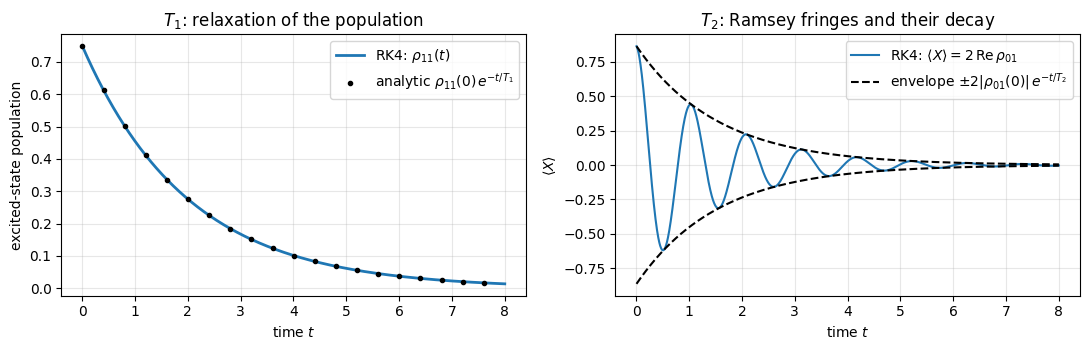

In [4]:
# ==============================================================================
# PARAMETERS  (single qubit: decay + dephasing + detuning)
# ==============================================================================
gamma_1   = 0.5      # decay rate           -> T1 = 1/gamma_1 = 2
gamma_phi = 0.2      # dephasing rate       -> 1/T2 = gamma_1/2 + 2 gamma_phi = 0.65
delta     = 6.0      # detuning (Ramsey fringe frequency)
dt_1q     = 0.004    # RK4 time step
T_1q      = 8.0      # total time
theta0    = 2 * np.pi / 3

n_1q = int(round(T_1q / dt_1q))
psi0 = jnp.array([np.cos(theta0 / 2), np.sin(theta0 / 2)], dtype=CDTYPE)
rho0_1q = jnp.outer(psi0, psi0.conj())

H_1q = -0.5 * delta * Z
f_1q = lambda r: lindblad_rhs_dense(r, H_1q, [SM, Z], [gamma_1, gamma_phi])

# record the full 2x2 matrix after every step (tiny), so we can look at populations AND coherences
_, rho_t = jax.jit(lambda r: integrate(lambda y: rk4_step(f_1q, y, dt_1q), r, n_1q, lambda y: y))(rho0_1q)
t_1q = dt_1q * np.arange(1, n_1q + 1)

# ------------------------------------------------------------------------------
# analytic reference, Eq. (3)
# ------------------------------------------------------------------------------
T1, T2 = 1 / gamma_1, 1 / (gamma_1 / 2 + 2 * gamma_phi)
p1_exact  = float(jnp.real(rho0_1q[1, 1])) * np.exp(-t_1q / T1)
c01_exact = complex(rho0_1q[0, 1]) * np.exp(1j * delta * t_1q) * np.exp(-t_1q / T2)

err_p1  = float(np.max(np.abs(np.asarray(rho_t[:, 1, 1]).real - p1_exact)))
err_c01 = float(np.max(np.abs(np.asarray(rho_t[:, 0, 1]) - c01_exact)))
print(f"T1 = {T1:.3f},  T2 = {T2:.4f}   (2 T1 = {2 * T1:.1f})")
print(f"max |rho_11(t) - analytic| = {err_p1:.2e}")
print(f"max |rho_01(t) - analytic| = {err_c01:.2e}")
TOL_RK4 = max(1e-7, 10 * TOL)      # RK4 truncation error here is ~1e-8 or below; leave room for single precision
assert err_p1 < TOL_RK4 and err_c01 < TOL_RK4

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(t_1q, np.asarray(rho_t[:, 1, 1]).real, lw=2, label=r"RK4: $\rho_{11}(t)$")
ax[0].plot(t_1q[::100], p1_exact[::100], "k.", label=r"analytic $\rho_{11}(0)\,e^{-t/T_1}$")
ax[0].set_xlabel(r"time $t$"); ax[0].set_ylabel("excited-state population")
ax[0].set_title(r"$T_1$: relaxation of the population"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(t_1q, 2 * np.asarray(rho_t[:, 0, 1]).real, lw=1.5, label=r"RK4: $\langle X\rangle = 2\,\mathrm{Re}\,\rho_{01}$")
env = 2 * abs(complex(rho0_1q[0, 1])) * np.exp(-t_1q / T2)
ax[1].plot(t_1q, env, "k--", label=r"envelope $\pm2|\rho_{01}(0)|\,e^{-t/T_2}$"); ax[1].plot(t_1q, -env, "k--")
ax[1].set_xlabel(r"time $t$"); ax[1].set_ylabel(r"$\langle X\rangle$")
ax[1].set_title(r"$T_2$: Ramsey fringes and their decay"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretation.** The numerical populations and coherences agree with Eq. (3) to the accuracy of the integrator
(the printed errors are of order $10^{-9}$ or smaller). Left: the excited-state population decays exponentially with $T_1=2$. Right: the
coherence oscillates at the detuning and dies under the envelope $e^{-t/T_2}$ with $T_2\approx1.54 < 2T_1 = 4$,
because dephasing adds to the unavoidable relaxation-induced loss of coherence. This is precisely how $T_1$ and $T_2$
of a real qubit are *measured*: prepare, wait, read out, fit an exponential.

### 3.4 Analytic solution II: a driven qubit — optical Bloch equations

Now drive the decaying qubit resonantly: $H=\tfrac\Omega2 X$ (rotating frame, $\Omega$ = Rabi frequency), $L=\sigma^-$ with rate $\gamma$.
Parametrise $\rho = \tfrac12(\mathbb 1 + xX+yY+zZ)$ with the Bloch vector $(x,y,z)=(\langle X\rangle,\langle Y\rangle,\langle Z\rangle)$, i.e.
$\rho_{11} = (1-z)/2$ and $\rho_{01} = (x-iy)/2$.

* *Drive.* $-i[\tfrac\Omega2X,\rho]$ rotates the Bloch vector about the $x$ axis: $\dot{\vec r} = \Omega\,\hat x\times\vec r$, i.e. $\dot y = -\Omega z$, $\dot z = +\Omega y$.
* *Decay.* From Section 3.1: $\dot\rho_{11}=-\gamma\rho_{11}$ gives $\dot z = -2\dot\rho_{11} = \gamma(1-z)$, and
  $\dot\rho_{01} = -\tfrac\gamma2\rho_{01}$ gives $\dot x=-\tfrac\gamma2x$, $\dot y = -\tfrac\gamma2 y$.

Together, the **optical Bloch equations**

$$ \dot x = -\tfrac\gamma2 x,\qquad \dot y = -\Omega z-\tfrac\gamma2 y,\qquad \dot z = \Omega y+\gamma(1-z). \tag{4}$$

*Steady state* ($\dot x=\dot y=\dot z=0$): $y=-2\Omega z/\gamma$ inserted into the last equation gives

$$ z_{\rm ss} = \frac{\gamma^2}{\gamma^2+2\Omega^2},\qquad y_{\rm ss} = -\frac{2\Omega\gamma}{\gamma^2+2\Omega^2},\qquad x_{\rm ss}=0,
   \qquad \rho_{11}^{\rm ss} = \frac{1-z_{\rm ss}}2 = \frac{\Omega^2}{\gamma^2+2\Omega^2}. \tag{5}$$

However hard we drive, the excited-state population never exceeds $1/2$ (**saturation**): drive and decay balance in a
*mixed* state. *Transient:* the $(y,z)$ block of Eq. (4) has the eigenvalues $\lambda_\pm = -\tfrac34\gamma\pm\sqrt{\gamma^2/16-\Omega^2}$.
For $\Omega>\gamma/4$ these are complex: **damped Rabi oscillations** at frequency $\sqrt{\Omega^2-\gamma^2/16}$ with damping rate $\tfrac34\gamma$.

Because Eq. (4) is a linear ODE $\dot{\vec r} = M\vec r + \vec b$, its exact solution is
$\vec r(t) = \vec r_{\rm ss} + e^{Mt}(\vec r(0)-\vec r_{\rm ss})$, which we evaluate with a $3\times3$ matrix exponential as
reference for the *whole* time trace.

steady state, Eq. (5):  (x, y, z) = (+0.000000, -0.242424, +0.030303)
RK4 at t = 16:       (x, y, z) = (+0.000000, -0.243084, +0.032612)
max over all times |Bloch vector (RK4) - exact solution of Eq. (4)| = 2.79e-09


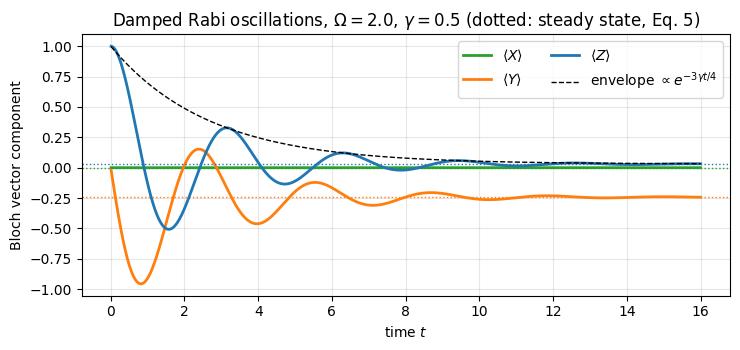

In [5]:
# ==============================================================================
# PARAMETERS  (driven-dissipative qubit)
# ==============================================================================
Omega   = 2.0       # Rabi frequency
gamma_d = 0.5       # decay rate
dt_d, T_d = 0.01, 16.0
n_d = int(round(T_d / dt_d))

H_d = 0.5 * Omega * X
f_d = lambda r: lindblad_rhs_dense(r, H_d, [SM], [gamma_d])
rho_start = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)                   # |0><0|: the qubit starts in its lower level
_, bloch_t = jax.jit(lambda r: integrate(lambda y: rk4_step(f_d, y, dt_d), r, n_d, bloch_vector))(rho_start)
t_d = dt_d * np.arange(1, n_d + 1)

# ------------------------------------------------------------------------------
# exact solution of the optical Bloch equations (4):  r(t) = r_ss + expm(M t) (r(0) - r_ss)
# ------------------------------------------------------------------------------
M_bloch = jnp.array([[-gamma_d / 2, 0, 0], [0, -gamma_d / 2, -Omega], [0, Omega, -gamma_d]], dtype=RDTYPE)
den = gamma_d ** 2 + 2 * Omega ** 2
r_ss = jnp.array([0.0, -2 * Omega * gamma_d / den, gamma_d ** 2 / den], dtype=RDTYPE)
r_init = jnp.array([0.0, 0.0, 1.0], dtype=RDTYPE)
bloch_exact = jax.vmap(lambda t: r_ss + jax.scipy.linalg.expm(M_bloch * t) @ (r_init - r_ss))(jnp.asarray(t_d, dtype=RDTYPE))

err_bloch = float(jnp.max(jnp.abs(bloch_t - bloch_exact)))
print(f"steady state, Eq. (5):  (x, y, z) = ({float(r_ss[0]):+.6f}, {float(r_ss[1]):+.6f}, {float(r_ss[2]):+.6f})")
print(f"RK4 at t = {T_d:g}:       (x, y, z) = ({float(bloch_t[-1, 0]):+.6f}, {float(bloch_t[-1, 1]):+.6f}, {float(bloch_t[-1, 2]):+.6f})")
print(f"max over all times |Bloch vector (RK4) - exact solution of Eq. (4)| = {err_bloch:.2e}")
assert err_bloch < TOL_RK4

fig, ax = plt.subplots(figsize=(7.5, 3.6))
for k, (lab, c) in enumerate(zip([r"$\langle X\rangle$", r"$\langle Y\rangle$", r"$\langle Z\rangle$"], ["C2", "C1", "C0"])):
    ax.plot(t_d, bloch_t[:, k], color=c, lw=2, label=lab)
    ax.axhline(float(r_ss[k]), color=c, ls=":", lw=1)
ax.plot(t_d, float(r_ss[2]) + (1 - float(r_ss[2])) * np.exp(-0.75 * gamma_d * t_d), "k--", lw=1, label=r"envelope $\propto e^{-3\gamma t/4}$")
ax.set_xlabel(r"time $t$"); ax.set_ylabel("Bloch vector component")
ax.set_title(rf"Damped Rabi oscillations, $\Omega={Omega}$, $\gamma={gamma_d}$ (dotted: steady state, Eq. 5)")
ax.legend(ncol=2); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

**Interpretation.** The qubit starts in $|0\rangle$ ($z=1$), the drive rotates the Bloch vector in the $y$–$z$ plane, and
the decay damps the rotation with the predicted rate $\tfrac34\gamma$ until the vector comes to rest at the steady state
of Eq. (5), *inside* the Bloch ball: $|\vec r_{\rm ss}|<1$ means a mixed state. The RK4 trace agrees with the exact
solution of the Bloch equations to $\sim10^{-9}$ at all times.

### 3.5 A parameter sweep with `vmap`: the saturation curve

`jax.vmap` turns a function written for **one** value of $\Omega$ into a function of a whole array of values, executed
as one batched computation. We integrate to $t=30/\gamma$ (many relaxation times) and compare the final excited-state
population with Eq. (5).

max |rho_11(steady) - Omega^2/(gamma^2 + 2 Omega^2)| over the sweep = 3.74e-09


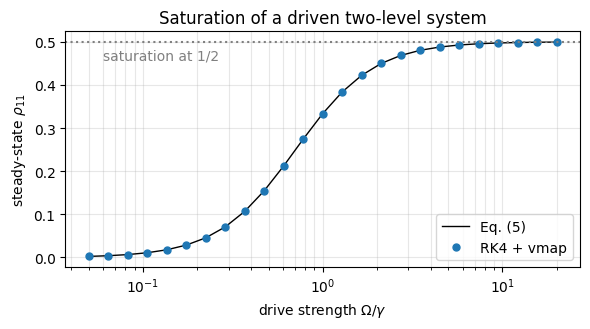

In [6]:
# ==============================================================================
# Saturation curve: steady-state excited population versus drive strength (vmap over Omega)
# ==============================================================================
def excited_population_at_late_time(Om, gamma=gamma_d, dt=0.01, n_steps=6000):
    """Integrate the driven, decaying qubit to t = n_steps*dt and return rho_11 = (1 - <Z>)/2."""
    f = lambda r: lindblad_rhs_dense(r, 0.5 * Om * X, [SM], [gamma])
    rho, _ = integrate(lambda y: rk4_step(f, y, dt), rho_start, n_steps, lambda y: 0.0)
    return jnp.real(rho[1, 1])

Omegas = jnp.asarray(np.geomspace(0.05, 20.0, 25) * gamma_d, dtype=RDTYPE)
p1_num = jax.jit(jax.vmap(excited_population_at_late_time))(Omegas)       # 25 integrations in ONE compiled call
p1_ana = Omegas ** 2 / (gamma_d ** 2 + 2 * Omegas ** 2)
err_sat = float(jnp.max(jnp.abs(p1_num - p1_ana)))
print(f"max |rho_11(steady) - Omega^2/(gamma^2 + 2 Omega^2)| over the sweep = {err_sat:.2e}")
assert err_sat < 1e-6

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.semilogx(Omegas / gamma_d, p1_ana, "k-", lw=1, label="Eq. (5)")
ax.semilogx(Omegas / gamma_d, p1_num, "o", ms=5, label="RK4 + vmap")
ax.axhline(0.5, color="gray", ls=":"); ax.text(0.06, 0.46, "saturation at 1/2", color="gray")
ax.set_xlabel(r"drive strength $\Omega/\gamma$"); ax.set_ylabel(r"steady-state $\rho_{11}$")
ax.set_title("Saturation of a driven two-level system"); ax.legend(); ax.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

**Interpretation.** Weak drive ($\Omega\ll\gamma$): $\rho_{11}\approx(\Omega/\gamma)^2$, the qubit hardly leaves $|0\rangle$. Strong drive: the
population saturates at $1/2$ — the reason why an incoherently broadened two-level system can never be inverted by
a continuous resonant drive (and why lasers need three or four levels). The remaining deviation ($\lesssim10^{-7}$) is
dominated by the finite integration time, not by RK4.

> **Numerical practice.** We now have a Lindblad solver that passes three analytic tests. It is *dense*: for $N$ spins
> `H @ rho` costs $O(8^N)$. It will survive in this notebook only as a reference for $N\le4$.

## 4. The matrix-free Lindbladian on the density tensor

### 4.1 The density tensor (recap)

For $N$ spins, $\rho$ is a $2^N\times2^N$ matrix. As in
[notebook 07 (Chapter 3)](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb) we store it as a **tensor of rank $2N$**

$$ \rho[\underbrace{s_0,\dots,s_{N-1}}_{\text{ket axes }0\ldots N-1};\;\underbrace{s'_0,\dots,s'_{N-1}}_{\text{bra axes }N\ldots 2N-1}]
   = \langle s_0\dots s_{N-1}|\,\rho\,|s'_0\dots s'_{N-1}\rangle , $$

which is nothing but `rho_matrix.reshape((2,)*(2*N))`; `dm_matrix(rho)` goes back. Spin $q$ owns **two** axes: its ket
axis `q` and its bra axis `N+q`.

### 4.2 The left/right multiplication trick

The Lindbladian (2) contains three kinds of products with a local operator $O$ (acting on site $q$, identity elsewhere).
Let us write them with indices; to keep the formulas short, suppress all spectator indices and write $\rho_{ab}$ with
$a$ = ket index and $b$ = bra index of site $q$.

**Left multiplication** acts on the *ket* index:

$$ (O\rho)_{ab} = \sum_c O_{ac}\,\rho_{cb}. $$

This is literally the formula of a gate acting on a state vector — `apply_gate(rho, O, [q])`.

**Right multiplication** acts on the *bra* index, but with the roles of row and column exchanged:

$$ (\rho\,O)_{ab} = \sum_c \rho_{ac}\,O_{cb} = \sum_c (O^{T})_{bc}\,\rho_{ac}. $$

Read the last expression as "the matrix $O^T$ acts on the bra index": `apply_gate(rho, O.T, [N+q])`.
It is the **transpose, not the Hermitian conjugate** — no complex conjugation appears, because we only re-ordered indices.

**Sandwich** $L\rho L^\dagger$: left-multiply by $L$, right-multiply by $L^\dagger$, whose transpose is $(L^\dagger)^T = L^*$:

$$ (L\rho L^\dagger)_{ab} = \sum_{c,d} L_{ac}\,L^*_{bd}\,\rho_{cd} . $$

`apply_gate(apply_gate(rho, L, [q]), L.conj(), [N+q])` — the same rule as "$U$ on kets, $U^*$ on bras" for unitary gates.

| product | acts on | with matrix | einsum for $N=2$, site $q=0$ (axes `a b ; c d` = ket0 ket1 ; bra0 bra1) |
|---|---|---|---|
| $O\rho$ | ket axis $q$ | $O$ | `"ea,abcd->ebcd"` |
| $\rho\,O$ | bra axis $N+q$ | $O^T$ | `"ec,abcd->abed"` |
| $L\rho L^\dagger$ | both | $L$ and $L^*$ | `"ea,fc,abcd->ebfd"` |

Each contraction touches every element of $\rho$ once and multiplies by a $2\times2$ matrix: cost $O(2\cdot4^N)$, memory
$O(4^N)$, compared with $O(8^N)$ for `H @ rho` with a dense $2^N\times2^N$ Hamiltonian. Two-site terms (the bonds of $H$)
work the same way with a $4\times4$ matrix reshaped to $(2,2,2,2)$ acting on the axes $(q_1,q_2)$ or $(N+q_1,N+q_2)$.

### 4.3 By hand for two qubits

We verify the three strings of the table against ordinary matrix algebra with `kron`, and check that `apply_gate`
produces the same numbers.

In [7]:
# ==============================================================================
# STEP 2: left / right multiplication and the sandwich as einsums -- by hand, N = 2, site q = 0
# ==============================================================================
N2 = 2
key = jax.random.PRNGKey(2024)
k_a, k_b, k_op = jax.random.split(key, 3)
# a generic MIXED test state: 0.6 |a><a| + 0.4 |b><b| with Haar-random |a>, |b>
rho_test = 0.6 * to_dm(haar_state(k_a, N2)) + 0.4 * to_dm(haar_state(k_b, N2))          # shape (2,2,2,2)
O = jax.random.normal(k_op, (2, 2)) + 1j * jax.random.normal(jax.random.split(k_op)[0], (2, 2))   # generic, NOT Hermitian
O = O.astype(CDTYPE)

R = dm_matrix(rho_test)                       # 4 x 4 matrix view
O_full = jnp.kron(O, jnp.eye(2, dtype=CDTYPE))   # O on site 0 (left kron factor), identity on site 1

left     = jnp.einsum("ea,abcd->ebcd", O, rho_test)                 # O rho        : O   on ket axis 0
right    = jnp.einsum("ec,abcd->abed", O.T, rho_test)               # rho O        : O^T on bra axis 2 = N+0
sandwich = jnp.einsum("ea,fc,abcd->ebfd", O, O.conj(), rho_test)    # O rho O^dag  : O on ket, O^* on bra

checks = {
    "O rho        (by-hand einsum)": (left, O_full @ R),
    "rho O        (by-hand einsum)": (right, R @ O_full),
    "O rho O^dag  (by-hand einsum)": (sandwich, O_full @ R @ O_full.conj().T),
    "O rho        (apply_gate, ket axis)": (apply_gate(rho_test, O, [0]), O_full @ R),
    "rho O        (apply_gate, bra axis, O^T)": (apply_gate(rho_test, O.T, [N2 + 0]), R @ O_full),
}
for name, (a, b) in checks.items():
    err = float(jnp.max(jnp.abs(dm_matrix(a) - b)))
    print(f"{name:45s} max error = {err:.1e}")
    assert err < TOL
# the classic mistakes: using O^dagger or O^* instead of O^T on the bra axis.
# These lines are checkpoints too -- they assert that the wrong choice FAILS loudly, which is only
# guaranteed because O is neither symmetric nor real.
for label, Ow in [("O^dagger", O.conj().T), ("O^*", O.conj()), ("O (no transpose)", O)]:
    err_w = float(jnp.max(jnp.abs(dm_matrix(apply_gate(rho_test, Ow, [N2 + 0])) - R @ O_full)))
    print(f"{'rho O with ' + label + ' on the bra axis (WRONG)':45s} max error = {err_w:.1e}")
    assert err_w > 0.1

O rho        (by-hand einsum)                 max error = 0.0e+00
rho O        (by-hand einsum)                 max error = 0.0e+00
O rho O^dag  (by-hand einsum)                 max error = 0.0e+00
O rho        (apply_gate, ket axis)           max error = 0.0e+00
rho O        (apply_gate, bra axis, O^T)      max error = 0.0e+00
rho O with O^dagger on the bra axis (WRONG)   max error = 1.0e+00
rho O with O^* on the bra axis (WRONG)        max error = 1.3e+00
rho O with O (no transpose) on the bra axis (WRONG) max error = 6.6e-01


All three strings reproduce the dense products to machine precision, and `apply_gate` — written for state vectors —
does the job on the bra axes as well, provided we hand it $O^T$. The last three lines show what happens with
$O^\dagger$, $O^*$ or $O$ instead: an error of order one in each case.

> **Common pitfall.** For a Hermitian operator $O^T = O^*$, and for a *real* Hermitian one ($X$, $Z$, $XX$, $ZZ$, ...)
> even $O^T=O$, so a wrong transpose/conjugate can stay unnoticed for a long time. It strikes as soon as a $Y$ appears
> (e.g. in the $YY$ coupling of the Heisenberg model) or a non-Hermitian $L=\sigma^-$. Always test with a *generic complex* operator.

### 4.4 The general function

With the trick in hand the Lindbladian for any number of spins is two loops: one over the Hamiltonian terms
(commutator = left minus right multiplication), one over the jump operators (sandwich minus half the anticommutator).
This is the engine's `lindblad_rhs`; `lindblad_rk4_step` is `rk4_step` of Section 3 with this right-hand side.
The cell below shows both verbatim (together with `apply_gate`, on which they depend).

In [8]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 10. Open systems: Lindblad master equation (density tensor) and quantum trajectories (MCWF)
# ----------------------------------------------------------------------------
def lindblad_rhs(rho, terms, jumps):
    """Right-hand side of the Lindblad (GKSL) master equation, matrix-free:
        d rho/dt = -i[H, rho] + sum_j gamma_j ( L_j rho L_j^dag - (1/2){L_j^dag L_j, rho} ).
    `jumps` = [(qubits, L, gamma), ...].

    KEY TRICK   left multiplication  O rho  acts on KET axes with O;
                right multiplication rho O  acts on BRA axes with O^T     [ (rho O)_{ab} = sum_c rho_{ac} O_{cb} ].
                So every term is again `apply_gate` on a rank-2N tensor.
    """
    N = rho.ndim // 2
    out = jnp.zeros_like(rho)
    for q, h in terms:
        bq = [N + x for x in q]
        out = out - 1j * (apply_gate(rho, h, q) - apply_gate(rho, jnp.asarray(h).T, bq))
    for q, L, g in jumps:
        L = jnp.asarray(L, dtype=CDTYPE)
        bq = [N + x for x in q]
        LdL = L.conj().T @ L
        out = out + g * (apply_gate(apply_gate(rho, L, q), jnp.conj(L), bq)
                         - 0.5 * apply_gate(rho, LdL, q) - 0.5 * apply_gate(rho, LdL.T, bq))
    return out

def lindblad_rk4_step(rho, terms, jumps, dt):
    """Classical 4th-order Runge-Kutta step for d rho/dt = L(rho): local error O(dt^5).
    TRACE   conserved to round-off: every term of the Lindblad generator is traceless and the step is a linear
            combination of generator evaluations.  This holds even beyond the stability limit, so a correct trace
            does NOT certify a healthy run.
    POSITIVITY   not guaranteed: small negative eigenvalues appear for moderate dt, and the run blows up once
            dt * ||L|| exceeds the RK4 stability bound."""
    f = lambda r: lindblad_rhs(r, terms, jumps)
    k1 = f(rho)
    k2 = f(rho + 0.5 * dt * k1)
    k3 = f(rho + 0.5 * dt * k2)
    k4 = f(rho + dt * k3)
    return rho + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


Count the work: every Hamiltonian term costs 2 einsums, every jump operator 4. For a chain with $N-1$ bonds, $N$
fields and $N$ jump operators that is $2(2N-1)+4N \approx 8N$ contractions of cost $O(4^N)$ each:
**$O(N\,4^N)$ per evaluation of $\mathcal L(\rho)$, and never more than a few copies of $\rho$ in memory.**

### 4.5 Checkpoint: matrix-free versus two dense references

*Reference A* is the literal `lindblad_rhs_dense` of Section 3 fed with dense $2^N\times2^N$ operators. We obtain those with
`dense_hamiltonian`, which builds the matrix of any list of local terms from its matrix-free action (it does not
care whether the "Hamiltonian" is Hermitian, so it embeds $\sigma^-_q$ just as well).

*Reference B* is the **superoperator**: since $\mathcal L$ is linear, we may flatten $\rho$ into a vector of length $4^N$
and write $\mathcal L$ as a $4^N\times4^N$ matrix. With C-ordered (row-major) flattening, `rho.reshape(-1)`, the rule is

$$ \mathrm{vec}(A\rho B) = (A\otimes B^{T})\,\mathrm{vec}(\rho),\qquad\text{because}\quad
   (A\rho B)_{ij} = \sum_{kl}A_{ik}\,(B^T)_{jl}\;\rho_{kl}, $$

hence

$$ \hat{\mathcal L} = -i\,(H\otimes\mathbb 1 - \mathbb 1\otimes H^T) + \sum_j\gamma_j\Big(L_j\otimes L_j^* - \tfrac12\,L_j^\dagger L_j\otimes\mathbb 1 - \tfrac12\,\mathbb 1\otimes(L_j^\dagger L_j)^T\Big). \tag{6}$$

(Compare with Section 4.2: it is the same trick, written with Kronecker products.) The superoperator has $16^N$
entries — $N=6$ would need 268 MB, $N=7$ already 4.3 GB — but for $N\le4$ it gives us the exact propagator
$e^{\hat{\mathcal L}t}$, the exact steady state (null vector) and the full spectrum. Validation cells like the next one
are the only place where big matrices are allowed.

In [9]:
# ==============================================================================
# VALIDATION (small N only): dense operators and the dense superoperator, Eq. (6)
# ==============================================================================
def dense_jump_ops(jumps, N):
    """Dense 2^N x 2^N matrices of the local jump operators (validation only).
    `dense_hamiltonian` embeds ANY list of local terms; it does not require Hermiticity."""
    return [dense_hamiltonian([(q, L)], N) for q, L, _ in jumps]


def dense_liouvillian(terms, jumps, N):
    """The Lindbladian as a 4^N x 4^N matrix acting on rho.reshape(-1)  (validation only).

    MATH   vec(A rho B) = (A kron B^T) vec(rho)   for C-ordered flattening, hence Eq. (6).
    COST   16^N numbers: N <= 4 in practice.
    """
    d = 2 ** N
    Id = jnp.eye(d, dtype=CDTYPE)
    Hd = dense_hamiltonian(terms, N)
    Ls = -1j * (jnp.kron(Hd, Id) - jnp.kron(Id, Hd.T))
    for Ld, (_, _, g) in zip(dense_jump_ops(jumps, N), jumps):
        LdL = Ld.conj().T @ Ld
        Ls = Ls + g * (jnp.kron(Ld, Ld.conj()) - 0.5 * jnp.kron(LdL, Id) - 0.5 * jnp.kron(Id, LdL.T))
    return Ls


# ------------------------------------------------------------------------------
# test system: N = 3 XXZ chain in a transverse field, generic mixed state, decay AND dephasing on every site
# ------------------------------------------------------------------------------
N3 = 3
terms3 = heisenberg_terms(N3, Jxx=1.0, Jyy=1.0, Jzz=0.5, hx=1.0)
jumps3 = [((q,), SM, 0.3) for q in range(N3)] + [((q,), Z, 0.2) for q in range(N3)]
ka, kb = jax.random.split(jax.random.PRNGKey(7))
rho3 = 0.7 * to_dm(haar_state(ka, N3)) + 0.3 * to_dm(haar_state(kb, N3))

rhs_free = lindblad_rhs(rho3, terms3, jumps3)                                             # matrix-free
rhs_A = lindblad_rhs_dense(dm_matrix(rho3), dense_hamiltonian(terms3, N3),
                           dense_jump_ops(jumps3, N3), [g for _, _, g in jumps3])          # reference A
rhs_B = (dense_liouvillian(terms3, jumps3, N3) @ rho3.reshape(-1))                        # reference B

err_A = float(jnp.max(jnp.abs(dm_matrix(rhs_free) - rhs_A)))
err_B = float(jnp.max(jnp.abs(rhs_free.reshape(-1) - rhs_B)))
print(f"matrix-free vs literal dense formula : max error = {err_A:.1e}")
print(f"matrix-free vs superoperator Eq. (6) : max error = {err_B:.1e}")
print(f"Tr L(rho) = {complex(jnp.trace(dm_matrix(rhs_free))):.1e}   (must vanish: trace conservation)")
print(f"|| L(rho) - L(rho)^dagger || = {float(jnp.linalg.norm(dm_matrix(rhs_free) - dm_matrix(rhs_free).conj().T)):.1e}   (Hermiticity conservation)")
assert err_A < TOL and err_B < TOL

matrix-free vs literal dense formula : max error = 1.2e-16
matrix-free vs superoperator Eq. (6) : max error = 1.7e-16
Tr L(rho) = -5.6e-17-2.9e-34j   (must vanish: trace conservation)


|| L(rho) - L(rho)^dagger || = 2.8e-16   (Hermiticity conservation)


Three independent implementations agree to machine precision, on a generic complex state, with two-site terms, a
non-Hermitian jump operator and a $YY$ coupling in the game. The two extra lines verify properties of the *equation*:
$\mathcal L(\rho)$ is traceless and Hermitian, so the exact flow conserves $\mathrm{Tr}\rho$ and $\rho=\rho^\dagger$.

## 5. Time stepping I: Euler and Runge–Kutta with `lax.scan`

$\dot\rho = \mathcal L(\rho)$ is a linear system of $4^N$ ordinary differential equations. The formal solution
$\rho(t) = e^{\mathcal Lt}\rho(0)$ needs the exponential of a $4^N\times4^N$ matrix — out of the question. Explicit ODE
integrators need only what we have: the action $\rho\mapsto\mathcal L(\rho)$.

* **Euler**: $\rho(t+dt) = \rho + dt\,\mathcal L(\rho)$. This is the first-order Taylor expansion of $e^{\mathcal L dt}$:
  local error $O(dt^2)$, and after $T/dt$ steps a global error $O(dt)$.
* **RK4**: for a *linear* equation the four stages of `rk4_step` reproduce the Taylor series of the exponential up to
  fourth order, $\rho(t+dt) = \big(1 + dt\mathcal L + \tfrac{dt^2}{2}\mathcal L^2+\tfrac{dt^3}{6}\mathcal L^3+\tfrac{dt^4}{24}\mathcal L^4\big)\rho$:
  local error $O(dt^5)$, global error $O(dt^4)$, at the price of four evaluations of $\mathcal L$ per step.

**Stability.** Apply either scheme to one eigenmode, $\dot y=\lambda y$: each step multiplies $y$ by the polynomial
$P(\lambda\,dt)$. The scheme is stable if $|P|\le1$. The eigenvalues of $\mathcal L$ have imaginary parts as large as the
spread of the energy differences, $|{\rm Im}\lambda|\le E_{\max}-E_{\min}=:W$, and small negative real parts of the order of
the rates. For purely imaginary $\lambda=i\omega$, Euler gives $|1+i\omega dt|=\sqrt{1+\omega^2dt^2}>1$: **always unstable**
(we met this in [notebook 04 (Chapter 2)](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb)); only a sufficiently strong damping
rescues it. For RK4, $P(z)=1+z+\tfrac{z^2}{2}+\tfrac{z^3}{6}+\tfrac{z^4}{24}$ and the set $|P(z)|\le1$ — the stability
region — meets the imaginary axis on $|{\rm Im}\,z|\le2\sqrt2\approx2.83$ and the negative real axis on
$|{\rm Re}\,z|\le2.785$. The Lindbladian populates both directions: imaginary parts up to $W$ from the coherent
dynamics, real parts up to $R:=\max_k|{\rm Re}\,\lambda_k|$ from the dissipation, bounded by
$R\le\sum_j\gamma_j\lVert L_j^\dagger L_j\rVert$, which for $N$ sites with one jump operator each is $R\lesssim N\gamma$.
The practical rule is therefore

$$ dt \;\lesssim\; \min\!\left(\frac{2\sqrt2}{W},\;\frac{2.785}{R}\right),\qquad
   W = E_{\max}-E_{\min},\qquad R \lesssim N\gamma. \tag{7}$$

Both bounds tighten as $N$ grows: for a spin chain $W$ is extensive, $W\propto N$, so the affordable step shrinks like
$1/N$ — the same $1/N$ that we met for explicit integrators of the Schrödinger equation. In every experiment of this
notebook $R\ll W$ (weak baths), so the first bound is the binding one and we quote it as $dt<2.83/W$. Eq. (7) is an
estimate, not a theorem: the RK4 stability region is not a rectangle. A *small* negative real part moves a mode
slightly *deeper* into the region (the region bulges just to the left of the imaginary axis), which is why the measured
limit can sit a per cent above $2\sqrt2/W$; once $R\,dt\gtrsim0.6$ the region narrows again and the true limit falls
below both bounds. The only way to know the exact limit for a given $\mathcal L$ is to compute
$\max_k|P(\lambda_k dt)|$ — or to bisect on the simulation itself (Exercise 5).

### 5.1 A convergence experiment that compiles only once per method

To *measure* the orders we integrate the $N=3$ test problem to $T=2$ with several $dt$ and compare with the exact
$e^{\hat{\mathcal L}T}\rho_0$ from the dense superoperator.

> **JAX practice.** `lax.scan(..., length=n)` needs a *static* number of steps: a new $n$ means a new compilation.
> For a parameter study where only the final state matters we use **`lax.fori_loop(0, n, body, init)`** instead, which accepts a
> *traced* upper bound: one compilation serves all values of `n` and `dt`. (The price: no stacked outputs and no
> reverse-mode differentiation — irrelevant here.)

In [10]:
# ==============================================================================
# STEP 3: convergence study.  final_state(step)(rho0, dt, n): n steps of size dt, n and dt TRACED
# ==============================================================================
def make_final_state(step):
    """Turn step(rho, dt) -> rho into a jitted function (rho0, dt, n) -> rho(n*dt), compiled once for all dt, n."""
    @jax.jit
    def final_state(rho0, dt, n):
        return lax.fori_loop(0, n, lambda i, r: step(r, dt), rho0)
    return final_state


euler_step3 = lambda r, dt: r + dt * lindblad_rhs(r, terms3, jumps3)
rk4_step3   = lambda r, dt: lindblad_rk4_step(r, terms3, jumps3, dt)

T_conv = 2.0
n_list = [25, 50, 100, 200, 400, 800]
rho_exact = (jax.scipy.linalg.expm(dense_liouvillian(terms3, jumps3, N3) * T_conv) @ rho3.reshape(-1)).reshape(rho3.shape)

def convergence(step):
    fs = make_final_state(step)
    return [float(jnp.linalg.norm(fs(rho3, T_conv / n, n) - rho_exact)) for n in n_list]

errs = {"Euler": convergence(euler_step3), "RK4": convergence(rk4_step3)}
print("   dt      " + "".join(f"{k:>12s}" for k in errs))
for i, n in enumerate(n_list):
    print(f"{T_conv / n:8.5f}   " + "".join(f"{errs[k][i]:12.2e}" for k in errs))
order = lambda e: np.log2(e[-2] / e[-1])
print("measured order (last two dt):  " + ",  ".join(f"{k}: {order(v):.2f}" for k, v in errs.items()))
assert abs(order(errs["Euler"]) - 1) < 0.2 and abs(order(errs["RK4"]) - 4) < 0.3

   dt             Euler         RK4
 0.08000       3.04e+00    4.18e-04
 0.04000       2.39e-01    2.56e-05
 0.02000       5.57e-02    1.58e-06
 0.01000       2.10e-02    9.80e-08
 0.00500       9.28e-03    6.11e-09
 0.00250       4.39e-03    3.81e-10
measured order (last two dt):  Euler: 1.08,  RK4: 4.00


Halving $dt$ halves the Euler error (order 1) and divides the RK4 error by $\approx16$ (order 4). At the coarsest step Euler is
not merely inaccurate but *explosive*: an error of $3$ for a quantity whose norm satisfies $\|\rho\|_F\le1$ means the computed "state"
has nothing to do with a density matrix any more. That is the instability on the imaginary axis discussed above. We postpone the plot until the third competitor has joined.

## 6. Time stepping II: the Trotter–Kraus step

RK4 treats $\rho$ as an anonymous vector of numbers. Nothing in it knows that $\rho$ must stay positive. The
alternative is a **structure-preserving** step built only from operations that are physical by themselves — unitary
gates and Kraus channels. It is also the natural language of noisy quantum circuits ("gate, then noise"), and the
form that can be unravelled into quantum trajectories in the next notebook.

**Step 1: split coherent and dissipative dynamics.** Write $\mathcal L = \mathcal L_H+\mathcal L_D$ with
$\mathcal L_H(\rho)=-i[H,\rho]$ and $\mathcal L_D=\sum_j\gamma_j\mathcal D[L_j]$. As in
[TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb),

$$ e^{(\mathcal L_H+\mathcal L_D)dt} = e^{\mathcal L_Ddt}\,e^{\mathcal L_Hdt} + O(dt^2), $$

with the error controlled by the commutator $[\mathcal L_H,\mathcal L_D]$.

**Step 2: the coherent part** is $e^{\mathcal L_Hdt}\rho = U\rho U^\dagger$ with $U=e^{-iHdt}$, and $U$ is approximated by the
second-order TEBD gate sequence `tebd_gates(terms, dt, order=2)`, applied to kets ($U$) and bras ($U^*$) by `apply_gates_dm`.

**Step 3: the dissipative part.** For each jump operator we use the two-element Kraus channel from Section 2.3,

$$ K_1 = \sqrt{\gamma\,dt}\,L,\qquad K_0 = \sqrt{\mathbb 1-\gamma\,dt\,L^\dagger L}\; \big(= \mathbb 1-\tfrac12\gamma\,dt\,L^\dagger L + O(dt^2)\big). $$

The matrix square root (instead of the first-order expression) makes $K_0^\dagger K_0+K_1^\dagger K_1=\mathbb 1$ hold
**exactly**, for any $dt<1/(\gamma\|L\|^2)$. This is the engine's `kraus_from_jump(L, gamma*dt)`; the channel is applied with
`apply_kraus_dm` (one einsum summing over both Kraus branches). Expanding,
$K_0\rho K_0^\dagger+K_1\rho K_1^\dagger = \rho+dt\,\gamma\,\mathcal D[L](\rho)+O(dt^2)$ — the dissipator, to first order.

*Exactly trace preserving is not the same as exact.* The channel is a legitimate CPTP map for every $dt$, but it is the
wrong one at order $dt^2$. For $L=\sigma^-$ it is $K_0={\rm diag}(1,\sqrt{1-\gamma dt})$, $K_1=\sqrt{\gamma dt}\,\sigma^-$:
the amplitude-damping channel of notebook 07 with $g=\gamma\,dt$, whereas the exact solution of Section 3.1 requires
$g=1-e^{-\gamma dt}=\gamma dt-\tfrac12(\gamma dt)^2+\dots$. For $L=\sigma^z$ it is the dephasing channel with
$p=\gamma\,dt$ instead of the exact $p=(1-e^{-2\gamma dt})/2$. Both discrepancies are $O(dt^2)$ per step, hence $O(dt)$
after $T/dt$ steps: this is the *second* source of first-order error, independent of the splitting of Step 1, and
Section 6.1 removes it.

The complete step, `lindblad_trotter_step_dm(rho, gates, jump_kraus)`: all gates, then one channel per jump operator.

| | RK4 | Trotter–Kraus |
|---|---|---|
| global error | $O(dt^4)$ | $O(dt)$ |
| trace | conserved (linear invariant) | conserved (completeness) |
| positivity | **not** guaranteed | guaranteed (CPTP by construction) |
| stability | $dt\lesssim2\sqrt2/W$, Eq. (7) | unconditional |
| cost per step | $4\times$ Lindbladian $\approx 32N$ einsums | $\approx 2\cdot2(2N-1)+N$ einsums |

### 6.1 Strang splitting with exact local channels

Two independent first-order errors limit the step above: the ordering $e^{\mathcal L_Ddt}e^{\mathcal L_Hdt}$ and the
first-order Kraus pair. Both can be cured for our jump operators:

* dissipators on *different sites commute*, and for a single site $e^{\gamma dt\,\mathcal D[L]}$ is known **exactly**: from
  Section 3.1, decay for a time $dt$ is the amplitude-damping channel with $g=1-e^{-\gamma dt}$, and dephasing multiplies
  coherences by $e^{-2\gamma dt}=1-2p$, i.e. it is the dephasing channel with $p=(1-e^{-2\gamma dt})/2$;
* the symmetric (Strang) ordering $e^{\mathcal L_Hdt/2}\,e^{\mathcal L_Ddt}\,e^{\mathcal L_Hdt/2}$ has a local error $O(dt^3)$.

The result is a **second-order, completely positive** step at essentially the same cost. We define it here in the
notebook (`lindblad_strang_step_dm`) and let the convergence experiment judge.

In [11]:
# ==============================================================================
# STEP 4: Trotter-Kraus step (engine) and a second-order Strang variant with exact local channels
# ==============================================================================
def exact_local_kraus(L_name, gamma_dt):
    """Kraus operators of exp(gamma dt D[L]) for a single site -- EXACT for any dt.

    MATH   L = sigma^- : amplitude damping with g = 1 - exp(-gamma dt)          (rho_11 -> rho_11 e^{-gamma dt})
           L = sigma^z : dephasing with        p = (1 - exp(-2 gamma dt)) / 2   (rho_01 -> rho_01 e^{-2 gamma dt})
    """
    if L_name == "decay":
        return kraus_amplitude_damping(1.0 - jnp.exp(-gamma_dt))
    if L_name == "dephasing":
        return kraus_dephasing(0.5 * (1.0 - jnp.exp(-2.0 * gamma_dt)))
    raise ValueError("L_name must be 'decay' or 'dephasing'")


def lindblad_strang_step_dm(rho, half_gates, site_kraus):
    """Second-order completely positive Lindblad step:  U(dt/2) . exp(L_D dt) . U(dt/2).

    MATH   exp(L dt) = exp(L_H dt/2) exp(L_D dt) exp(L_H dt/2) + O(dt^3)
    IMPLEMENTATION   half_gates = tebd_gates(terms, dt/2, order=2);  site_kraus = [(qubits, exact Kraus set), ...].
                     Channels on different sites commute, so their product is exp(L_D dt) exactly.
    """
    rho = apply_gates_dm(rho, half_gates)
    for q, K in site_kraus:
        rho = apply_kraus_dm(rho, K, q)
    return apply_gates_dm(rho, half_gates)


def trotter_kraus_step3(r, dt):
    gates = tebd_gates(terms3, dt, order=2)
    jump_kraus = [(q, kraus_from_jump(L, g * dt)) for q, L, g in jumps3]
    return lindblad_trotter_step_dm(r, gates, jump_kraus)


def strang_step3(r, dt):
    half_gates = tebd_gates(terms3, dt / 2, order=2)
    site_kraus = [(q, exact_local_kraus("decay" if L is SM else "dephasing", g * dt)) for q, L, g in jumps3]
    return lindblad_strang_step_dm(r, half_gates, site_kraus)


# sanity: both Kraus constructions are complete, sum_m K_m^dag K_m = 1
for name, K in [("kraus_from_jump(sigma^-, 0.05)", kraus_from_jump(SM, 0.05)),
                ("exact_local_kraus('dephasing', 0.05)", exact_local_kraus("dephasing", 0.05))]:
    dev = float(jnp.max(jnp.abs(jnp.einsum("mab,mac->bc", jnp.conj(K), K) - jnp.eye(2))))
    print(f"completeness of {name:38s}: {dev:.1e}")
    assert dev < TOL

errs["Trotter-Kraus"] = convergence(trotter_kraus_step3)
errs["Strang + exact channels"] = convergence(strang_step3)
print("\n   dt      " + "".join(f"{k:>26s}" for k in errs))
for i, n in enumerate(n_list):
    print(f"{T_conv / n:8.5f}   " + "".join(f"{errs[k][i]:26.2e}" for k in errs))
print("measured order (last two dt):  " + ",  ".join(f"{k}: {order(v):.2f}" for k, v in errs.items()))
assert abs(order(errs["Trotter-Kraus"]) - 1) < 0.2 and abs(order(errs["Strang + exact channels"]) - 2) < 0.2

completeness of kraus_from_jump(sigma^-, 0.05)        : 1.1e-16
completeness of exact_local_kraus('dephasing', 0.05)  : 0.0e+00



   dt                           Euler                       RK4             Trotter-Kraus   Strang + exact channels
 0.08000                     3.04e+00                  4.18e-04                  1.18e-02                  2.19e-04
 0.04000                     2.39e-01                  2.56e-05                  5.89e-03                  5.46e-05
 0.02000                     5.57e-02                  1.58e-06                  2.95e-03                  1.36e-05
 0.01000                     2.10e-02                  9.80e-08                  1.47e-03                  3.41e-06
 0.00500                     9.28e-03                  6.11e-09                  7.37e-04                  8.52e-07
 0.00250                     4.39e-03                  3.81e-10                  3.68e-04                  2.13e-07
measured order (last two dt):  Euler: 1.08,  RK4: 4.00,  Trotter-Kraus: 1.00,  Strang + exact channels: 2.00


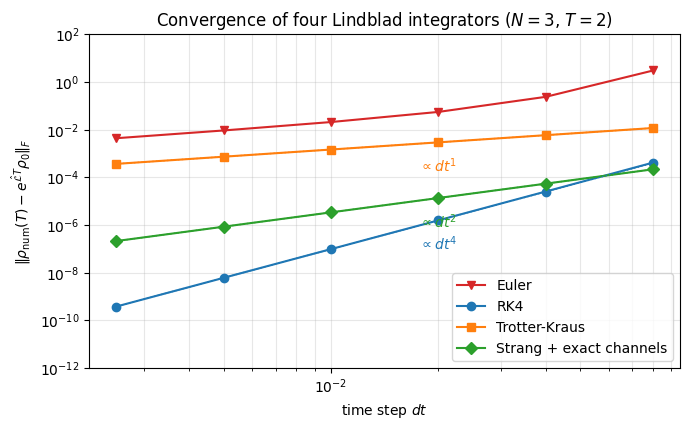

In [12]:
# ==============================================================================
# Convergence plot: error at T = 2 versus time step, with reference slopes
# ==============================================================================
dts = T_conv / np.array(n_list)
fig, ax = plt.subplots(figsize=(7, 4.4))
style = {"Euler": ("C3", "v"), "RK4": ("C0", "o"), "Trotter-Kraus": ("C1", "s"), "Strang + exact channels": ("C2", "D")}
for k, e in errs.items():
    ax.loglog(dts, e, marker=style[k][1], color=style[k][0], lw=1.5, label=k)
for p, c, ref in [(1, "C1", errs["Trotter-Kraus"][-1]), (2, "C2", errs["Strang + exact channels"][-1]), (4, "C0", errs["RK4"][-1])]:
    ax.loglog(dts, ref * (dts / dts[-1]) ** p, ":", color=c, lw=1)
    # annotate each reference slope BELOW its own line, at an intermediate dt where the three are well separated
    # (labelling at the right edge would push dt^2 and dt^4 on top of each other)
    x_lab = dts[2]
    ax.text(x_lab, 0.25 * ref * (x_lab / dts[-1]) ** p, rf"$\propto dt^{p}$", color=c, ha="center", va="top")
ax.set_ylim(1e-12, 1e2)
ax.set_xlabel(r"time step $dt$"); ax.set_ylabel(r"$\|\rho_{\rm num}(T)-e^{\hat{\mathcal{L}}T}\rho_0\|_F$")
ax.set_title(rf"Convergence of four Lindblad integrators ($N={N3}$, $T={T_conv:g}$)")
ax.legend(loc="lower right"); ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

**Interpretation.** The measured slopes are the predicted ones: 1 (Euler, Trotter–Kraus), 2 (Strang with exact local
channels) and 4 (RK4). Two lessons:

* *Order is not everything.* Euler and Trotter–Kraus are both first order, but at equal $dt$ the Trotter–Kraus error is
  one to two orders of magnitude smaller and it never explodes, because it treats the fast, purely oscillatory Hamiltonian part with
  unitary gates; only the (slow) dissipation and the splitting are handled to first order.
* For accuracy at fixed cost RK4 wins by a large margin on the density tensor. The Kraus-type steps win on
  *robustness* (next section) and they are the only ones that carry over to **pure-state trajectories**, where the memory drops from $4^N$ to $2^N$.

## 7. Trace, Hermiticity, positivity: what the integrators preserve

A simulation of $\rho$ should be monitored the way a closed-system simulation monitors the norm and the energy:

* $\mathrm{Tr}\rho-1$ and $\|\rho-\rho^\dagger\|$: conserved by the exact flow because $\mathcal L(\rho)$ is traceless and Hermitian
  (Section 4.5). Any Runge–Kutta method conserves such **linear invariants** exactly, up to round-off: every stage is a linear
  combination of traceless Hermitian increments.
* $\lambda_{\min}(\rho)\ge0$: positivity is a *nonlinear* constraint (it bounds eigenvalues), and nothing in RK4 knows about it.
  A pure initial state is the most delicate case: it sits on the boundary of the set of density matrices, with $2^N-1$
  eigenvalues exactly zero — the slightest truncation error pushes some of them below zero.

We evolve an $N=4$ chain from $|0000\rangle$ and record the three diagnostics after every step with `lax.scan`
(the eigenvalues of a $16\times16$ matrix are cheap). The spectral width is $W\approx12.6$ while the damping scale is only
$R\lesssim N\gamma=0.4$, so the first bound of Eq. (7) is the binding one and predicts that RK4 becomes unstable for
$dt\gtrsim2\sqrt2/W\approx0.22$.

In [13]:
# ==============================================================================
# PARAMETERS  (diagnostics experiment)
# ==============================================================================
N4 = 4
gamma4 = 0.1
terms4 = heisenberg_terms(N4, Jxx=1.0, Jyy=1.0, Jzz=0.5, hx=1.0)
jumps4 = [((q,), SM, gamma4) for q in range(N4)]                      # decay on every site
rho0_4 = to_dm(zero_state(N4))
T_diag = 10.0

E4 = np.linalg.eigvalsh(np.asarray(dense_hamiltonian(terms4, N4)))   # validation-size dense matrix (16 x 16)
W4 = E4[-1] - E4[0]
print(f"spectral width W = E_max - E_min = {W4:.2f}   ->  RK4 stability limit dt < 2.83/W = {2.83 / W4:.3f}")


def diagnostics(rho):
    """(Tr rho - 1,  ||rho - rho^dag||_F,  smallest eigenvalue of the Hermitian part of rho)."""
    m = dm_matrix(rho)
    return jnp.stack([jnp.real(jnp.trace(m)) - 1.0,
                      jnp.linalg.norm(m - m.conj().T),
                      jnp.linalg.eigvalsh(0.5 * (m + m.conj().T))[0]])


def run_diagnostics(method, dt):
    n = int(round(T_diag / dt))
    if method == "RK4":
        step = lambda r: lindblad_rk4_step(r, terms4, jumps4, dt)
    else:
        gates = tebd_gates(terms4, dt, order=2)
        jump_kraus = [(q, kraus_from_jump(L, g * dt)) for q, L, g in jumps4]
        step = lambda r: lindblad_trotter_step_dm(r, gates, jump_kraus)
    _, d = jax.jit(lambda r: integrate(step, r, n, diagnostics))(rho0_4)
    return dt * np.arange(1, n + 1), np.asarray(d)


runs = [("RK4", 0.05), ("RK4", 0.2), ("RK4", 0.25), ("Trotter-Kraus", 0.05), ("Trotter-Kraus", 0.25)]
diag = {}
print(f"\n{'method':>14s} {'dt':>6s} {'max|Tr rho - 1|':>16s} {'max||rho-rho^dag||':>19s} {'min eigenvalue':>15s}")
for method, dt in runs:
    diag[(method, dt)] = run_diagnostics(method, dt)
    d = diag[(method, dt)][1]
    print(f"{method:>14s} {dt:6.2f} {np.abs(d[:, 0]).max():16.1e} {d[:, 1].max():19.1e} {d[:, 2].min():15.2e}")

# ------------------------------------------------------------------------------
# CHECKPOINT: turn the three claims of this section into asserts.
#   (a) RK4 beyond the stability limit BLOWS UP   (b) yet still keeps the trace
#   (c) the Kraus step stays positive at the same dt.  An assert on the trace alone
#   could not distinguish (a) from a healthy run -- which is precisely the lesson.
# ------------------------------------------------------------------------------
d_blown = diag[("RK4", 0.25)][1]
assert d_blown[:, 2].min() < -1e3                       # (a) eigenvalues of order 1e8: unusable
assert np.abs(d_blown[:, 0]).max() < 1e-6               # (b) trace still 1 to 8 digits
assert diag[("Trotter-Kraus", 0.25)][1][:, 2].min() > -1e-12     # (c) positive to round-off
assert diag[("RK4", 0.05)][1][:, 2].min() < -1e-7       # RK4 does violate positivity, even when accurate

spectral width W = E_max - E_min = 12.56   ->  RK4 stability limit dt < 2.83/W = 0.225

        method     dt  max|Tr rho - 1|  max||rho-rho^dag||  min eigenvalue


           RK4   0.05          6.7e-16             0.0e+00       -2.06e-05


           RK4   0.20          4.4e-16             0.0e+00       -1.43e-02


           RK4   0.25          3.4e-08             0.0e+00       -3.68e+08


 Trotter-Kraus   0.05          2.9e-13             2.1e-15       -5.30e-22


 Trotter-Kraus   0.25          2.2e-13             9.6e-16        5.50e-17


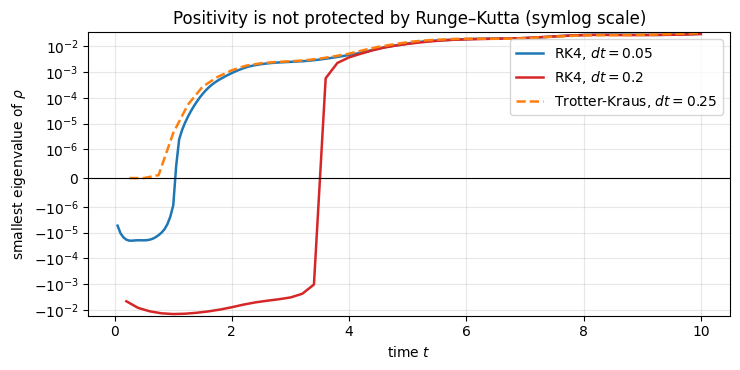

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for (method, dt), c, ls in [(("RK4", 0.05), "C0", "-"), (("RK4", 0.2), "C3", "-"), (("Trotter-Kraus", 0.25), "C1", "--")]:
    t, d = diag[(method, dt)]
    ax.plot(t, d[:, 2], color=c, ls=ls, lw=1.8, label=rf"{method}, $dt={dt}$")
ax.axhline(0, color="k", lw=0.8)
ax.set_yscale("symlog", linthresh=1e-6)
ax.set_xlabel(r"time $t$"); ax.set_ylabel(r"smallest eigenvalue of $\rho$")
ax.set_title("Positivity is not protected by Runge–Kutta (symlog scale)")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

**Interpretation** (compare the table with the figure).

* Trace and Hermiticity: **all five runs** keep them at round-off level, including RK4 with $dt=0.25$, which is beyond the stability
  limit (7) and has by then produced eigenvalues of size $4\times10^{8}$. This is the lesson of the experiment:
  trace and Hermiticity are *linear* invariants, so an explicit Runge–Kutta step preserves them **whatever** the solution does — the
  $3\times10^{-8}$ residue in the unstable run is only round-off amplified by the huge entries. A trace of $1.000000$ is therefore no
  evidence at all that a density-matrix simulation is healthy. Monitor the purity or the smallest eigenvalue as well.
* Positivity: RK4 produces slightly **negative eigenvalues** at early times, when $\rho$ is still nearly pure:
  $-2\times10^{-5}$ for $dt=0.05$ and $-1.4\times10^{-2}$ for $dt=0.2$ — the size of the truncation error. Later the dissipation
  moves $\rho$ into the interior of the set of states and the problem disappears (see the figure: the curves cross zero around $t\approx1$ and $t\approx3.5$).
  Harmless for local observables, but fatal if you compute $\log\rho$, $\sqrt\rho$ or a fidelity without care (this is why the engine clips eigenvalues in
  `von_neumann_entropy`).
* Trotter–Kraus stays positive to round-off ($-5\times10^{-22}$ at worst) even at the large step $dt=0.25$, where it is stable but of
  course not very accurate: *physical but wrong* is still wrong, so convergence in $dt$ must be checked for every method.

> **Numerical practice.** Choose RK4 with $dt\approx0.1\cdot(2\sqrt2/W)$ when you need accurate density matrices, and check
> $\lambda_{\min}$. Choose a Kraus-type step when positivity matters, when the model is a noisy circuit anyway, or when the same
> step must later be unravelled into trajectories.

## 8. Many-body physics: a dissipative spin chain

### 8.1 Model and questions

We now study the model that accompanies us through the rest of this chapter: the open XXZ chain in a transverse field,

$$ H = \sum_{i=0}^{N-2}\big(X_iX_{i+1}+Y_iY_{i+1}+\Delta\,Z_iZ_{i+1}\big)+h_x\sum_iX_i,\qquad \Delta=0.5,\; h_x=1, $$

with an independent bath on every site, prepared in $|00\dots0\rangle$ (all spins up). The field $h_x$
breaks the conservation of the total magnetisation, so the closed chain already shows non-trivial dynamics. We run three cases:

* **dephasing**, $L_i=Z_i$ with $\gamma=0.1$ — e.g. a fluctuating magnetic field along $z$;
* **decay**, $L_i=\sigma^-_i$ — every spin relaxes towards $|0\rangle$ (up), while the field $h_x$ keeps driving it away —
  once *weak* ($\gamma=0.1$) and once *strong* ($\gamma=1$), so that we can see which of bath and drive wins.

Questions: what is the long-time state? How fast is it approached? How mixed does the chain become?
Expectations from Section 2.4: dephasing is unital, so $\mathbb 1/2^N$ is a fixed point and the entropy can only grow;
we expect the chain to approach $\mathbb 1/2^N$ — purity $2^{-N}$, entropy $N$ bits — whatever $\gamma$ is.
Decay is not unital and *can* produce a **structured steady state** with finite magnetisation — but only if
it is strong enough to compete with $h_x$.

> **Common pitfall — unital does not mean "reaches $\mathbb 1/2^N$".** Unitality only says that $\mathbb 1/2^N$ is *a*
> fixed point; reaching it requires that it is the *only* one. Dephasing alone ($H=0$, $L_i=Z_i$) has a fixed point for
> every diagonal density matrix: it destroys coherences and then stops. The same happens if $H$ commutes with all the
> $Z_i$ — an Ising chain would freeze in its initial populations. Here $H$ contains $X_iX_{i+1}$, $Y_iY_{i+1}$ and
> $h_x\sum_iX_i$, which do not commute with the $Z_i$, and the numerics below confirm a unique steady state. The general
> criterion is quoted in Section 8.3.

### 8.2 From formula to code

* One jitted function `evolve_chain(rho0, L, gamma)` with `lax.scan` over RK4 steps. The jump matrix `L` and the rate are
  **traced arguments**: the same compiled program serves both environments (compilation is the expensive part for
  rank-12 tensors, see Section 9).
* Observables after every step: the magnetisation profile $\langle Z_q\rangle$ via `expect_local_dm` (partial trace by einsum),
  the purity $\mathrm{Tr}\rho^2=\sum_{ab}|\rho_{ab}|^2$ (valid for Hermitian $\rho$: no matrix product needed), the von Neumann entropy in bits
  (one `eigvalsh` of the $2^N\times2^N$ matrix) and the smallest eigenvalue as a health check.
* $dt=0.02$ is seven times below the RK4 stability limit for $N=6$ ($W\approx19.8$, so $2\sqrt2/W\approx0.14$).

In [15]:
# ==============================================================================
# PARAMETERS  (dissipative XXZ chain)
# ==============================================================================
N      = 6        # spins; the density tensor has 4^N = 4096 entries
Delta  = 0.5      # ZZ anisotropy
hx     = 1.0      # transverse field
gamma  = 0.1      # weak bath rate on every site (the strong-decay run below uses gamma_strong)
gamma_strong = 1.0
dt     = 0.02     # RK4 step
T_max  = 30.0     # total time
every  = 10       # record observables every `every` steps

terms = heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=Delta, hx=hx)
n_rec = int(round(T_max / dt / every))


def chain_observables(rho):
    """[<Z_0>, ..., <Z_{N-1}>, purity, entropy (bits), smallest eigenvalue] of a density tensor."""
    m = dm_matrix(rho)
    lam = jnp.linalg.eigvalsh(0.5 * (m + m.conj().T))
    lam_c = jnp.clip(lam, 1e-16, None)
    z = [expect_local_dm(rho, Z, [q]) for q in range(N)]
    return jnp.stack(z + [jnp.sum(jnp.abs(rho) ** 2), -jnp.sum(lam_c * jnp.log2(lam_c)), lam[0]])


@jax.jit
def evolve_chain(rho0, L, g):
    """RK4 evolution of the chain with the SAME single-site jump operator L (rate g) on every site.
    L and g are traced -> one compilation for all environments.  Returns (rho_final, observables[n_rec, N+3])."""
    jumps = [((q,), L, g) for q in range(N)]

    def block(rho):                                   # `every` RK4 steps between two recordings
        return lax.fori_loop(0, every, lambda i, r: lindblad_rk4_step(r, terms, jumps, dt), rho)

    return integrate(block, rho0, n_rec, chain_observables)


rho0 = to_dm(zero_state(N))
t0 = time.perf_counter()
rho_deph, obs_deph = evolve_chain(rho0, Z, gamma); obs_deph.block_until_ready()
t1 = time.perf_counter()
rho_dec, obs_dec = evolve_chain(rho0, SM, gamma); obs_dec.block_until_ready()
t2 = time.perf_counter()
rho_str, obs_str = evolve_chain(rho0, SM, gamma_strong); obs_str.block_until_ready()
print(f"dephasing run: {t1 - t0:6.2f} s  (includes compilation)")
print(f"decay run    : {t2 - t1:6.2f} s  (compiled program reused: L and gamma are traced arguments)")
t_rec = dt * every * np.arange(1, n_rec + 1)

scenarios = [(rf"dephasing, $\gamma={gamma}$", obs_deph, "C0"), (rf"decay, $\gamma={gamma}$", obs_dec, "C1"),
             (rf"decay, $\gamma={gamma_strong}$", obs_str, "C3")]
for name, o in [("dephasing g=0.1", obs_deph), ("decay g=0.1", obs_dec), ("decay g=1.0", obs_str)]:
    print(f"{name:16s} t={T_max:g}:  mean <Z> = {float(jnp.mean(o[-1, :N])):+.4f}   purity = {float(o[-1, N]):.5f}"
          f"   S = {float(o[-1, N + 1]):.4f} bits   min eigenvalue over run = {float(jnp.min(o[:, N + 2])):.1e}")
print(f"maximally mixed state: purity 2^-N = {2.0 ** -N:.5f}, entropy N = {N} bits")

dephasing run:  43.70 s  (includes compilation)
decay run    :  33.58 s  (compiled program reused: L and gamma are traced arguments)


dephasing g=0.1  t=30:  mean <Z> = +0.0000   purity = 0.01563   S = 6.0000 bits   min eigenvalue over run = -1.7e-07
decay g=0.1      t=30:  mean <Z> = +0.0097   purity = 0.01623   S = 5.9723 bits   min eigenvalue over run = -1.2e-06
decay g=1.0      t=30:  mean <Z> = +0.2017   purity = 0.07516   S = 4.7218 bits   min eigenvalue over run = -2.9e-07
maximally mixed state: purity 2^-N = 0.01562, entropy N = 6 bits


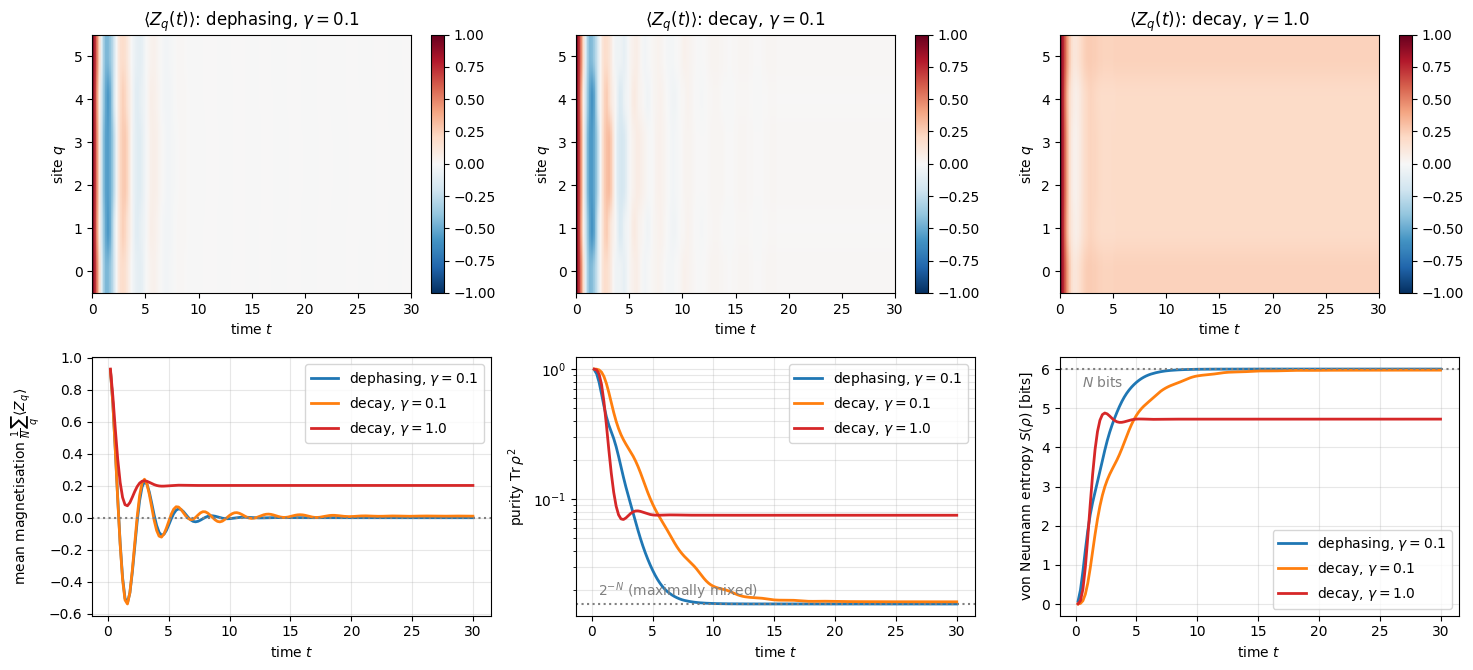

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(15, 6.8))
for col, (name, o, c) in enumerate(scenarios):
    im = ax[0, col].imshow(np.asarray(o[:, :N]).T, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-1, vmax=1,
                           extent=[0, T_max, -0.5, N - 0.5])
    ax[0, col].set_xlabel(r"time $t$"); ax[0, col].set_ylabel(r"site $q$"); ax[0, col].set_title(rf"$\langle Z_q(t)\rangle$: {name}")
    plt.colorbar(im, ax=ax[0, col])
    ax[1, 0].plot(t_rec, jnp.mean(o[:, :N], axis=1), color=c, lw=2, label=name)
    ax[1, 1].semilogy(t_rec, o[:, N], color=c, lw=2, label=name)
    ax[1, 2].plot(t_rec, o[:, N + 1], color=c, lw=2, label=name)
ax[1, 0].axhline(0, color="gray", ls=":")
ax[1, 0].set_xlabel(r"time $t$"); ax[1, 0].set_ylabel(r"mean magnetisation $\frac{1}{N}\sum_q\langle Z_q\rangle$"); ax[1, 0].legend(); ax[1, 0].grid(alpha=.3)
ax[1, 1].axhline(2.0 ** -N, color="gray", ls=":"); ax[1, 1].text(0.5, 2.0 ** -N * 1.15, r"$2^{-N}$ (maximally mixed)", color="gray")
ax[1, 1].set_xlabel(r"time $t$"); ax[1, 1].set_ylabel(r"purity $\mathrm{Tr}\,\rho^2$"); ax[1, 1].legend(); ax[1, 1].grid(alpha=.3, which="both")
ax[1, 2].axhline(N, color="gray", ls=":"); ax[1, 2].text(0.5, N - 0.45, r"$N$ bits", color="gray")
ax[1, 2].set_xlabel(r"time $t$"); ax[1, 2].set_ylabel(r"von Neumann entropy $S(\rho)$ [bits]"); ax[1, 2].legend(); ax[1, 2].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretation.**

* *Top row.* During the first few time units all three chains show the coherent many-body oscillations of the closed system
  (period of order $1/J$) — for the two $\gamma=0.1$ panels these are still essentially identical, because $\gamma t\ll1$;
  at $\gamma=1$ the bath wins immediately. Then the environments take over. Under dephasing every $\langle Z_q\rangle$ is damped to zero.
  Under *weak* decay ($\gamma=0.1$) the magnetisation is damped to zero as well, and only under *strong* decay ($\gamma=1$) does it
  settle at a clearly positive value $\approx+0.20$: the bath polarises the spins "up" while the field $h_x$ and the exchange
  coupling depolarise them, and which of the two wins is decided by the ratio $\gamma/h_x$.
* *Bottom row.* The purity falls from 1 and the entropy rises from 0: an initially pure state becomes mixed because the
  system gets entangled with the (traced-out) environment. With dephasing the chain reaches the maximally mixed state
  — purity $2^{-N}=0.0156$, entropy $N=6$ bits, to four digits: a bath that only scrambles phases, combined with a
  Hamiltonian that moves populations around, erases all information about the initial state. Weak decay ends up almost there too ($S=5.97$ bits): a bath that is much weaker
  than the drive cannot impose its own structure. Only strong decay produces a genuinely structured steady state,
  with purity $0.075$ and $S=4.72$ bits, well below $N$.
* The smallest eigenvalue over the whole run (printed above) never goes below $-1.2\times10^{-6}$: RK4 with this $dt$ is healthy.

### 8.3 Steady state, Liouvillian spectrum and the relaxation gap

A steady state satisfies $\mathcal L(\rho_{\rm ss})=0$: it is the eigenvector of the superoperator with eigenvalue 0.
All other eigenvalues $\lambda_k$ have $\mathrm{Re}\,\lambda_k\le0$ and describe decaying modes,
$\rho(t)=\rho_{\rm ss}+\sum_kc_k\,e^{\lambda_kt}R_k$. At long times the slowest mode dominates, so the distance to the
steady state decays like $e^{-\Delta_{\mathcal L}t}$ with the **Liouvillian gap**

$$ \Delta_{\mathcal L} = -\max_{\lambda_k\neq0}\mathrm{Re}\,\lambda_k . $$

This picture — one zero eigenvalue, everything else decaying — presupposes that the steady state is **unique**. It need
not be: a Lindbladian can have several zero eigenvalues (several steady states) or purely imaginary ones (persistent
oscillations). The classical sufficient condition is due to Spohn and Evans: *if the only operators that commute with
$H$ and with all the $L_j$ and $L_j^\dagger$ are multiples of $\mathbb 1$* (equivalently: $\{H, L_j, L_j^\dagger\}$
generates the full matrix algebra), then the semigroup is **irreducible**, the steady state is unique, and every
initial state converges to it. Any conserved quantity that survives the dissipation — a symmetry, a dark state, a
decoherence-free subspace — breaks the condition and splits the state space into non-communicating sectors. In practice
one checks the condition numerically the way the cell below does: by counting how many singular values of
$\hat{\mathcal L}$ are zero. A single zero (and a healthy gap to the next one) means a unique steady state.

For $N=4$ the dense superoperator ($256\times256$) is small enough to diagonalise, which gives us an independent
prediction for *both* the steady state and the relaxation rate of a matrix-free RK4 run. We obtain the null vector from
an SVD (the right-singular vector of the smallest singular value) and the spectrum from `numpy.linalg.eigvals`
(a non-Hermitian eigenproblem; validation only).

two smallest singular values of L: 1.3e-16, 0.458   -> the steady state is unique
eigenvalue closest to zero: -1.2e-14-2.9e-15j;   Liouvillian gap = 0.62447   (gamma = 1.0)


steady state: Hermitian to 1.3e-15, min eigenvalue 0.0031, purity 0.1677


|| rho_RK4(t=30) - rho_ss ||_F = 3.6e-10
fitted asymptotic decay rate = 0.62436   vs   Liouvillian gap = 0.62447


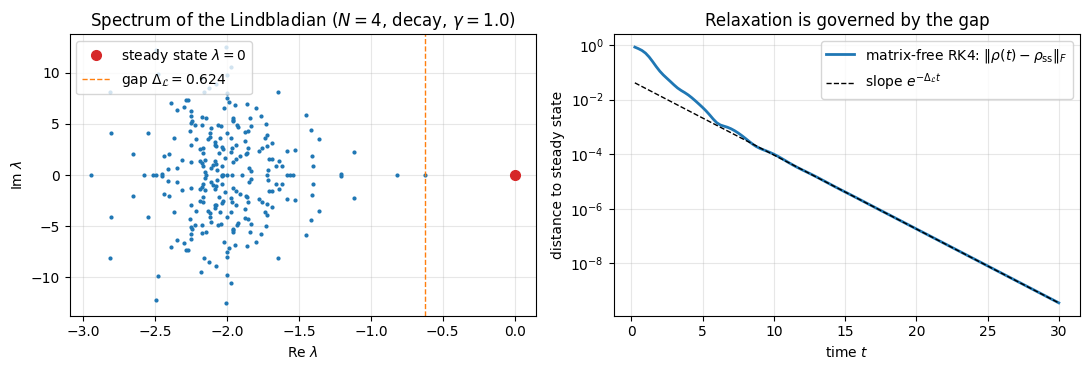

In [17]:
# ==============================================================================
# VALIDATION (N = 4): steady state and spectrum from the dense superoperator vs matrix-free RK4
# ==============================================================================
gamma_ss = 1.0
jumps4_ss = [((q,), SM, gamma_ss) for q in range(N4)]            # strong decay on every site of the N = 4 chain
Ls4 = dense_liouvillian(terms4, jumps4_ss, N4)                  # 256 x 256 superoperator
_, svals, Vh = jnp.linalg.svd(Ls4)
rho_ss = Vh[-1].conj().reshape(2 ** N4, 2 ** N4)                # null vector of the superoperator ...
rho_ss = rho_ss / jnp.trace(rho_ss)                             # ... normalised to unit trace
lam4 = np.linalg.eigvals(np.asarray(Ls4))
lam4 = lam4[np.argsort(-lam4.real)]
gap4 = -lam4[1].real
print(f"two smallest singular values of L: {float(svals[-1]):.1e}, {float(svals[-2]):.3f}   -> the steady state is unique")
print(f"eigenvalue closest to zero: {lam4[0]:.1e};   Liouvillian gap = {gap4:.5f}   (gamma = {gamma_ss})")
print(f"steady state: Hermitian to {float(jnp.linalg.norm(rho_ss - rho_ss.conj().T)):.1e}, "
      f"min eigenvalue {float(jnp.linalg.eigvalsh(0.5 * (rho_ss + rho_ss.conj().T))[0]):.4f}, purity {float(purity(rho_ss)):.4f}")

# matrix-free RK4 run to long times; distance to the exact steady state after every recording block
T_long, dt_long, every_long = 30.0, 0.05, 5
n_long = int(round(T_long / dt_long / every_long))
block4 = lambda rho: lax.fori_loop(0, every_long, lambda i, r: lindblad_rk4_step(r, terms4, jumps4_ss, dt_long), rho)
dist_fn = lambda rho: jnp.linalg.norm(dm_matrix(rho) - rho_ss)
rho_long, dist = jax.jit(lambda r: integrate(block4, r, n_long, dist_fn))(rho0_4)
t_long = dt_long * every_long * np.arange(1, n_long + 1)

err_ss = float(dist[-1])
sel = (t_long > 14) & (t_long < 26)                             # fit window: asymptotic regime, above round-off
rate_fit = -np.polyfit(t_long[sel], np.log(np.asarray(dist)[sel]), 1)[0]
print(f"|| rho_RK4(t={T_long:g}) - rho_ss ||_F = {err_ss:.1e}")
print(f"fitted asymptotic decay rate = {rate_fit:.5f}   vs   Liouvillian gap = {gap4:.5f}")
assert err_ss < 1e-6 and abs(rate_fit - gap4) < 0.02 * gap4

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(lam4.real, lam4.imag, ".", ms=4, color="C0")
ax[0].plot([0], [0], "o", color="C3", ms=7, label="steady state $\\lambda=0$")
ax[0].axvline(-gap4, color="C1", ls="--", lw=1, label=rf"gap $\Delta_{{\mathcal{{L}}}}={gap4:.3f}$")
ax[0].set_xlabel(r"Re $\lambda$"); ax[0].set_ylabel(r"Im $\lambda$"); ax[0].set_title(rf"Spectrum of the Lindbladian ($N={N4}$, decay, $\gamma={gamma_ss}$)")
ax[0].legend(loc="upper left"); ax[0].grid(alpha=.3)
ax[1].semilogy(t_long, dist, "C0", lw=2, label=r"matrix-free RK4: $\|\rho(t)-\rho_{\rm ss}\|_F$")
ax[1].semilogy(t_long, float(dist[np.argmax(sel)]) * np.exp(-gap4 * (t_long - t_long[np.argmax(sel)])), "k--", lw=1,
               label=r"slope $e^{-\Delta_{\mathcal{L}}t}$")
ax[1].set_xlabel(r"time $t$"); ax[1].set_ylabel("distance to steady state"); ax[1].set_title("Relaxation is governed by the gap")
ax[1].legend(); ax[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

**Interpretation.** *Left:* the $4^N=256$ eigenvalues of $\hat{\mathcal L}$ lie in the left half plane, symmetric about the real
axis (they come in complex-conjugate pairs because $\mathcal L$ maps Hermitian matrices to Hermitian matrices). Their imaginary
parts are energy differences of $H$ (coherent oscillations, $|{\rm Im}\lambda|\le W\approx12.6$ — the origin of the RK4 stability limit), their real parts are
damping rates between $0$ and $\approx3$, of the order of $N\gamma=4$. Exactly one eigenvalue is zero: a unique steady state. *Right:* the matrix-free RK4
evolution converges to the steady state obtained from linear algebra, and at late times the distance decays with the
rate given by the gap — two completely different numerical routes, one answer.

> **Physics insight.** The gap sets the longest relaxation time $1/\Delta_{\mathcal L}$ — here $1/0.624=1.6$, i.e. 60 % longer than the naive
> $1/\gamma=1$; in other models it can be much longer or shorter, depending on how the slowest mode overlaps with the jump operators. Gaps that close with
> increasing $N$ signal dissipative phase transitions, in analogy with the closing energy gap at a quantum phase transition.

### 8.4 Where the zero eigenvalue comes from, and what uniqueness buys

The cell above found *one* zero at $\gamma=1$ and called the steady state unique. Trace preservation guarantees that a
zero exists for any $\gamma$ whatsoever, so the informative number is not whether there is a zero but **how many**.
The clean way to see this is to switch the dissipator off and watch the count.

At $\gamma=0$ we have $\mathcal L=-i[H,\cdot]$. Its eigenoperators are $|m\rangle\langle n|$ built from energy
eigenstates, with eigenvalues $-i(E_m-E_n)$: the whole spectrum lies on the imaginary axis and nothing decays. Every
pair of states at the same energy gives a zero, so

$$ \#\{\lambda=0\}\big|_{\gamma=0} \;=\; \sum_m g_m^2 , $$

summed over the distinct levels with multiplicities $g_m$. A closed system therefore has many stationary states — every
function of $H$ is one — and no unique steady state at all. Switching the dissipator on lifts all of those zeros but one.

**Why uniqueness matters.** With exactly one zero: (i) every initial state relaxes to the same $\rho_{\rm ss}$, so it is a
property of $\mathcal L$ alone; (ii) $\rho_{\rm ss}$ inherits every symmetry of $\mathcal L$ (if $\mathcal S$ commutes with
$\mathcal L$ then $\mathcal S(\rho_{\rm ss})$ is stationary too, and uniqueness forces the two to be equal) — so a unique
steady state cannot spontaneously break a symmetry at finite $N$, and dissipative phase transitions are exactly the points
where the gap closes as $N\to\infty$; (iii) $\rho_{\rm ss}$ is obtainable as a null vector, with no time integration;
(iv) a single long trajectory time-averages to $\mathrm{tr}(O\rho_{\rm ss})$, which is what makes the Monte-Carlo wave
function of the next notebook usable for steady-state questions. A zero can also be built on purpose: a **dark state**, a pure state
annihilated by every $L_j$ and an eigenstate of $H$, is stationary by construction (decay alone, $H=0$, $L_i=\sigma^-_i$, has the dark
state $|0\dots0\rangle$ and no other steady state). When the dark state is the *only* zero every initial state is driven into it, and
engineering such a dark state is how dissipation becomes a tool for *preparing* states; two dark states give two zeros.

level multiplicities of H: [1, 1, 2, 1, 1, 1, 1]   ->  sum_m g_m^2 = 10
zeros of L found at gamma = 0 : 10
zeros of L for every gamma > 0: 1  (unique steady state throughout the sweep)
   gamma =  0.010:  gap = 0.0061
   gamma =  0.173:  gap = 0.1057
   gamma =  3.981:  gap = 2.1680


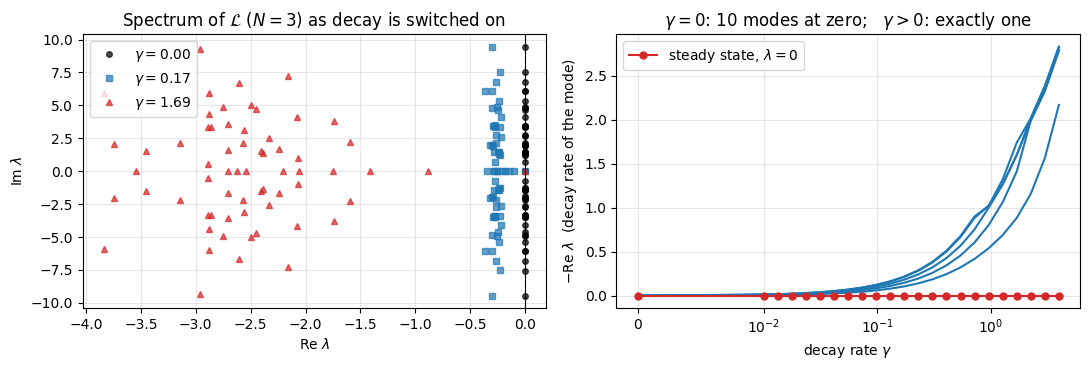

In [18]:
# ==============================================================================
# The spectrum of L against the decay rate: the zero survives, its degeneracy does not
# ==============================================================================
GAMMAS = np.concatenate([[0.0], np.logspace(-2, 0.6, 22)])
spec = {}
for gam in GAMMAS:
    jumps_g = [((q,), SM, gam) for q in range(N3)] if gam > 0 else []
    ev = np.linalg.eigvals(np.asarray(dense_liouvillian(terms3, jumps_g, N3)))
    spec[gam] = ev[np.argsort(-ev.real)]

n_zero = lambda ev, tol=1e-9: int(np.sum(np.abs(ev) < tol))
gap_of = lambda ev: -ev[n_zero(ev)].real

# the count at gamma = 0 predicted by the level multiplicities of H
_, mult = np.unique(np.round(np.linalg.eigvalsh(np.asarray(dense_hamiltonian(terms3, N3))), 8), return_counts=True)
print(f"level multiplicities of H: {list(map(int, mult))}   ->  sum_m g_m^2 = {int((mult ** 2).sum())}")
print(f"zeros of L found at gamma = 0 : {n_zero(spec[0.0])}")
assert n_zero(spec[0.0]) == int((mult ** 2).sum())
for gam in GAMMAS[1:]:
    assert n_zero(spec[gam]) == 1, "expected a unique steady state for every gamma > 0"
print(f"zeros of L for every gamma > 0: 1  (unique steady state throughout the sweep)")
for gam in (GAMMAS[1], GAMMAS[11], GAMMAS[-1]):
    print(f"   gamma = {gam:6.3f}:  gap = {gap_of(spec[gam]):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for gam, c, m in ((0.0, "k", "o"), (GAMMAS[11], "C0", "s"), (GAMMAS[-4], "C3", "^")):
    ax[0].plot(spec[gam].real, spec[gam].imag, m, ms=4, alpha=.7, color=c, label=rf"$\gamma={gam:.2f}$")
ax[0].axvline(0, color="k", lw=.8)
ax[0].set_xlabel(r"Re $\lambda$"); ax[0].set_ylabel(r"Im $\lambda$"); ax[0].set_title(rf"Spectrum of $\mathcal{{L}}$ ($N={N3}$) as decay is switched on")
ax[0].legend(); ax[0].grid(alpha=.3)
slow = np.array([np.sort(-spec[g].real)[:6] for g in GAMMAS])
ax[1].plot(GAMMAS, slow[:, 1:], "-", lw=1.5, color="C0")
ax[1].plot(GAMMAS, slow[:, 0], "o-", ms=5, color="C3", label=r"steady state, $\lambda=0$")
ax[1].set_xscale("symlog", linthresh=1e-2)
ax[1].set_xlabel(r"decay rate $\gamma$"); ax[1].set_ylabel(r"$-$Re $\lambda$  (decay rate of the mode)")
ax[1].set_title(rf"$\gamma=0$: {n_zero(spec[0.0])} modes at zero;   $\gamma>0$: exactly one")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretation.** *Left:* at $\gamma=0$ every eigenvalue sits on the imaginary axis — a closed system only oscillates.
Dissipation pushes the spectrum into the left half plane, and it stays there: no mode can grow, because a growing mode
would take $\rho$ out of the set of states. *Right:* the ten zeros of the closed system collapse to one as soon as
$\gamma>0$, and the gap to the next mode opens from there. That single surviving zero is the steady state; the distance
from it to the nearest mode is the inverse relaxation time measured in Section 8.3.

## 9. Cost: $O(4^N)$ memory, $O(N\,4^N)$ time, and where compile time goes

The density tensor has $4^N$ complex entries, 16 bytes each in double precision; RK4 holds about six such arrays
($\rho$, four stages, a temporary). A table of what that means (pure arithmetic):

In [19]:
# ==============================================================================
# Memory table: state vector 2^N  vs  density tensor 4^N  vs  dense superoperator 16^N   (bytes per amplitude from CDTYPE)
# ==============================================================================
def fmt_bytes(b):
    for unit in ["B", "kB", "MB", "GB", "TB", "PB", "EB"]:
        if b < 1000:
            return f"{b:7.1f} {unit}"
        b /= 1000
    return f"{b:7.1f} ZB"

itemsize = jnp.zeros((), dtype=CDTYPE).dtype.itemsize
print(f"{'N':>3s} {'state vector 2^N':>18s} {'density tensor 4^N':>20s} {'RK4 working set ~6x':>21s} {'superoperator 16^N':>20s}")
for n in [2, 4, 6, 8, 10, 12, 13, 14, 16, 20]:
    print(f"{n:3d} {fmt_bytes(itemsize * 2 ** n):>18s} {fmt_bytes(itemsize * 4 ** n):>20s} {fmt_bytes(6 * itemsize * 4 ** n):>21s} {fmt_bytes(itemsize * 16 ** n):>20s}")

  N   state vector 2^N   density tensor 4^N   RK4 working set ~6x   superoperator 16^N
  2             64.0 B              256.0 B                1.5 kB               4.1 kB
  4            256.0 B               4.1 kB               24.6 kB               1.0 MB
  6             1.0 kB              65.5 kB              393.2 kB             268.4 MB
  8             4.1 kB               1.0 MB                6.3 MB              68.7 GB
 10            16.4 kB              16.8 MB              100.7 MB              17.6 TB
 12            65.5 kB             268.4 MB                1.6 GB               4.5 PB
 13           131.1 kB               1.1 GB                6.4 GB              72.1 PB
 14           262.1 kB               4.3 GB               25.8 GB               1.2 EB
 16             1.0 MB              68.7 GB              412.3 GB             295.1 EB
 20            16.8 MB              17.6 TB              105.6 TB           19342.8 ZB


A laptop with 16 GB stops at $N=13$ for a single copy of $\rho$ (1 GB; about 6 GB for RK4) — and $N=14$ is already out of
reach. The state vector of the same 13 spins takes 131 kB. This factor $2^N$ is the motivation for the
[next notebook](17_monte_carlo_wave_function.ipynb).

Now the measured time per step. We time **one jitted step** for increasing $N$, separating the first call
(tracing + XLA compilation) from the steady-state run time, with `block_until_ready()` because JAX dispatches asynchronously.

  N      4^N |  RK4 first call [s]  RK4 step [ms] |  T-K first call [s]  T-K step [ms]
  2       16 |                1.36          0.450 |                0.53          0.215
  3       64 |                2.41          8.287 |                0.40          0.267
  4      256 |                3.69          1.782 |                0.51          0.525
  5     1024 |                6.52          8.166 |                0.81          0.810
  6     4096 |               12.15         25.053 |                0.77          2.641
  7    16384 |               16.35        155.644 |                0.90         16.149
  8    65536 |               22.89        617.648 |                1.59         86.125


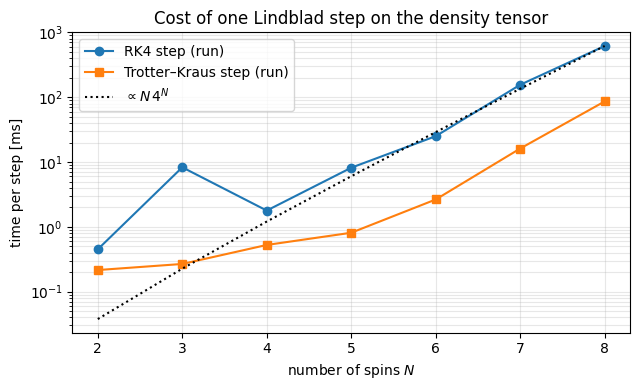

In [20]:
# ==============================================================================
# BENCHMARK: compile time and run time per step, RK4 vs Trotter-Kraus, as a function of N
# ==============================================================================
def benchmark_step(Nb, method, dt=0.02, g=0.1, repeats=3):
    terms_b = heisenberg_terms(Nb, Jxx=1.0, Jyy=1.0, Jzz=0.5, hx=1.0)
    jumps_b = [((q,), SM, g) for q in range(Nb)]
    if method == "RK4":
        step = jax.jit(lambda r: lindblad_rk4_step(r, terms_b, jumps_b, dt))
    else:
        gates = tebd_gates(terms_b, dt, order=2)
        jump_kraus = [(q, kraus_from_jump(L, gg * dt)) for q, L, gg in jumps_b]
        step = jax.jit(lambda r: lindblad_trotter_step_dm(r, gates, jump_kraus))
    rho = to_dm(zero_state(Nb))
    t0 = time.perf_counter(); step(rho).block_until_ready(); t_first = time.perf_counter() - t0
    t0 = time.perf_counter()
    for _ in range(repeats):
        rho = step(rho)
    rho.block_until_ready()
    return t_first, (time.perf_counter() - t0) / repeats


N_bench = [2, 3, 4, 5, 6, 7, 8]
bench = {m: np.array([benchmark_step(n, m) for n in N_bench]) for m in ("RK4", "Trotter-Kraus")}
print(f"{'N':>3s} {'4^N':>8s} | {'RK4 first call [s]':>19s} {'RK4 step [ms]':>14s} | {'T-K first call [s]':>19s} {'T-K step [ms]':>14s}")
for i, n in enumerate(N_bench):
    print(f"{n:3d} {4 ** n:8d} | {bench['RK4'][i, 0]:19.2f} {1e3 * bench['RK4'][i, 1]:14.3f} | "
          f"{bench['Trotter-Kraus'][i, 0]:19.2f} {1e3 * bench['Trotter-Kraus'][i, 1]:14.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
Nb = np.array(N_bench)
ax.semilogy(Nb, 1e3 * bench["RK4"][:, 1], "o-", color="C0", label="RK4 step (run)")
ax.semilogy(Nb, 1e3 * bench["Trotter-Kraus"][:, 1], "s-", color="C1", label="Trotter–Kraus step (run)")
ref = 1e3 * bench["RK4"][-1, 1] * (Nb / Nb[-1]) * 4.0 ** (Nb - Nb[-1])
ax.semilogy(Nb, ref, "k:", label=r"$\propto N\,4^N$")
ax.set_xlabel(r"number of spins $N$"); ax.set_ylabel("time per step [ms]")
ax.set_title("Cost of one Lindblad step on the density tensor"); ax.legend(); ax.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

**Interpretation.** (Absolute numbers depend on your machine; the trends do not.)

* For small $N$ both curves are far *shallower* than the $N\,4^N$ law (dotted): the arrays are tiny and the cost is per-operation
  overhead, not arithmetic. From $N\approx6$ on the RK4 step grows by a factor $\gtrsim4$ per added spin, as the cost model
  predicts, and by $N=8$ the RK4 curve has caught up with the dotted line.
* A Trotter–Kraus step is cheaper than an RK4 step — a factor $32/9\approx3.6$ by operation count ($\approx9N$ versus $32N$
  einsums). Do not read the measured ratio too closely: with three repetitions per point, on a machine that may be running
  other jobs, the table scatters by an order of magnitude from run to run (a non-monotonic entry in a column is noise, not
  physics). Whatever the constant, the Kraus step needs a much smaller $dt$ for the same accuracy (Section 6): for smooth,
  accurate density-matrix dynamics RK4 remains the better deal.
* The **first call** is dominated by compilation and it grows with $N$ too: XLA has to plan a few hundred transposes
  and contractions of rank-$2N$ tensors. This is why Section 8 compiled *one* program with traced `L` and `gamma` and reused it.

> **JAX practice.** Compile time scales with the size of the *program* (number of einsums $\propto N$, times 4 RK4 stages),
> run time with the size of the *data* ($4^N$). Keep programs small (scan/fori_loop instead of unrolled Python loops) and
> reuse compiled functions by making physical parameters traced arguments rather than Python constants.

## 10. Summary: key takeaways

* An open quantum system with a memoryless environment obeys the **GKSL/Lindblad equation**
  $\dot\rho=-i[H,\rho]+\sum_j\gamma_j(L_j\rho L_j^\dagger-\tfrac12\{L_j^\dagger L_j,\rho\})$. Demanding that the evolution over $dt$
  is a Kraus channel close to the identity produces it, with the anticommutator term fixed by trace conservation; the
  GKSL theorem states that nothing else is possible for a continuous CPTP *semigroup*. Born, Markov and secular
  approximations are what makes a real bath fit that description. The pair $(H,\{L_j\})$ is not unique: unitary mixing
  of the $L_j$ and the shift $L_j\to L_j+c_j$ (with a matching shift of $H$) leave $\mathcal L$ unchanged.
* One qubit: decay gives $T_1=1/\gamma_1$, coherences decay with $1/T_2=1/(2T_1)+1/T_\varphi$; a resonant drive plus decay gives
  damped Rabi oscillations (rate $\tfrac34\gamma$) and the saturating steady state $\rho_{11}=\Omega^2/(\gamma^2+2\Omega^2)$. Our codes
  reproduce all of this to $\sim10^{-9}$.
* **Left/right multiplication trick:** $O\rho$ = `apply_gate` with $O$ on ket axes, $\rho O$ = `apply_gate` with $O^T$ on bra axes,
  $L\rho L^\dagger$ = $L$ on kets and $L^*$ on bras. The Lindbladian costs $O(N4^N)$ time and $O(4^N)$ memory; no $2^N\times2^N$ product ever appears.
* **RK4**: fourth order, conserves trace and Hermiticity exactly, *not* positivity, and is unstable for $dt\gtrsim2\sqrt2/W$.
  **Trotter–Kraus**: first order (second order with Strang splitting and exact local channels), completely positive and unconditionally stable.
* Dephasing (unital noise) makes $\mathbb 1/2^N$ a fixed point; when it is the *only* one — which needs $H$ not to commute with
  the jump operators (Spohn–Evans irreducibility) — the chain approaches the maximally mixed state for any rate. Decay plus drive
  produces a structured steady state only when the decay can compete with the drive (here $\gamma\sim h_x$, not
  $\gamma=0.1$); relaxation at late times is governed by the Liouvillian gap.
* Always validate: analytic limits, the literal dense formula, the dense superoperator for $N\le4$, convergence orders,
  and the diagnostics $\mathrm{Tr}\rho$, $\|\rho-\rho^\dagger\|$, $\lambda_{\min}$.
* The $4^N$ wall stops density-tensor simulations at $N\approx13$. Trading the density matrix for an ensemble of pure
  states — quantum trajectories — is the subject of the [next notebook](17_monte_carlo_wave_function.ipynb).

## 11. Exercises

1. ★ **Pumping.** Add a second jump operator $\sigma^+$ with rate $\gamma_\uparrow$ to the decaying qubit of Section 3 (no drive).
   Derive the steady-state population $\rho_{11}^{\rm ss}=\gamma_\uparrow/(\gamma_\uparrow+\gamma_1)$ and the relaxation rate
   $\gamma_\uparrow+\gamma_1$, and verify both numerically. For which ratio $\gamma_\uparrow/\gamma_1$ is the steady state maximally mixed?
2. ★ **Bit-flip noise.** Replace dephasing by $L=X$ in the Ramsey experiment of Section 3.3 with $\delta=0$. Which Bloch-vector
   components decay, and at which rate? Derive it as in Section 3.1 and check.
3. ★★ **Detuned drive.** Add a detuning, $H=\tfrac\Omega2X-\tfrac\delta2Z$, to the optical Bloch equations (4), derive the
   steady-state population $\rho_{11}^{\rm ss} = \Omega^2/(\gamma^2+2\Omega^2+4\delta^2)$ and reproduce the Lorentzian line shape with a
   `vmap` over $\delta$. What is its width at strong drive ("power broadening")?
4. ★★ **Extend the code: Heisenberg picture.** Write `lindblad_adjoint_rhs(O, terms, jumps)` for the adjoint equation
   $\dot O=+i[H,O]+\sum_j\gamma_j(L_j^\dagger OL_j-\tfrac12\{L_j^\dagger L_j,O\})$ using the same left/right trick on an operator
   tensor, evolve $O=Z_0$ and verify $\mathrm{Tr}(\rho(t)O)=\mathrm{Tr}(\rho_0O(t))$ for the $N=3$ test problem.
5. ★★ **Stability limit.** For the $N=4$ chain of Section 7 find the largest stable RK4 step by bisection (criterion:
   purity $\le1.01$ at $T=50$) and compare with $2\sqrt2/W$. Repeat with $\gamma=2$: the limit changes by only a few per
   cent — why so little, given that the damping rate has grown by a factor 20? (Compare $R\,dt$ with $W\,dt$.)
6. ★★ **Physics: size of the steady-state magnetisation.** For the decaying, driven chain of Section 8 compute the
   steady-state $\langle Z\rangle$ as a function of $h_x\in[0,3]$ at $N=4$ (null vector of the superoperator) and at $N=6$
   (long RK4 run). Compare with the single-qubit formula (5) with $\Omega=2h_x$. Where and why do interactions matter?
7. ★★★ **Second-order Kraus step for arbitrary $L$.** `exact_local_kraus` knows only two jump operators. For a general
   single-site $L$, build the exact channel numerically: exponentiate the $4\times4$ single-site superoperator
   $\gamma\,dt\,\hat{\mathcal D}[L]$, reshuffle it into the Choi matrix, and obtain Kraus operators from its eigendecomposition.
   Verify second-order convergence of `lindblad_strang_step_dm` for $L=\sigma^x$.
8. ★★★ **Gap versus system size.** Compute the Liouvillian gap of the dephasing chain for $N=2,3,4$ from the dense
   superoperator and for $N=5,6$ from the late-time decay of $\|\rho(t)-\mathbb 1/2^N\|$ in a matrix-free run. How does it scale
   with $N$ and with $\gamma$?

## 12. References

* G. Lindblad, *On the generators of quantum dynamical semigroups*, Commun. Math. Phys. **48**, 119 (1976).
* V. Gorini, A. Kossakowski, E. C. G. Sudarshan, *Completely positive dynamical semigroups of N-level systems*, J. Math. Phys. **17**, 821 (1976).
* H. Spohn, *An algebraic condition for the approach to equilibrium of an open N-level system*, Lett. Math. Phys. **2**, 33–38 (1977);
  D. E. Evans, *Irreducible quantum dynamical semigroups*, Commun. Math. Phys. **54**, 293–297 (1977) — uniqueness of the steady state (Section 8.3).
* H.-P. Breuer, F. Petruccione, *The Theory of Open Quantum Systems*, Oxford University Press (2002) — chapter 3 ("Quantum Master Equations"): the microscopic Born–Markov–secular derivation.
* D. Manzano, *A short introduction to the Lindblad master equation*, AIP Advances **10**, 025106 (2020) — a self-contained derivation at introductory level.
* M. A. Nielsen, I. L. Chuang, *Quantum Computation and Quantum Information*, Cambridge University Press (2000) — chapter 8 ("Quantum noise and quantum operations"): the operator-sum representation and, in §8.3, the amplitude-damping and phase-damping channels used here.
* A. J. Daley, *Quantum trajectories and open many-body quantum systems*, Adv. Phys. **63**, 77 (2014) — open many-body systems and the methods of the next notebook.
* E. Hairer, S. P. Nørsett, G. Wanner, *Solving Ordinary Differential Equations I: Nonstiff Problems*, 2nd revised ed., Springer Series in Computational Mathematics **8**, Springer (1993) — Runge–Kutta methods, order conditions and stability regions.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling, B. P. Flannery, *Numerical Recipes: The Art of Scientific Computing*, 3rd ed., Cambridge University Press (2007) — chapter 17 ("Integration of Ordinary Differential Equations"), §17.1 the Runge–Kutta method and §17.2 adaptive step-size control; the same algorithms appear in W. H. Press *et al.*, *Numerical Recipes in Fortran 90*, 2nd ed., Cambridge University Press (1996).

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644) · [GitHub](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*.

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/